# CardioGraph: End-to-End Medical Knowledge Graph Pipeline

**Stack:** PubMed (MEDLINE) · MeSH Ontology · Mistral (HuggingFace) · Neo4j · NetworkX · SentenceTransformers

---
**Modules:**
1. Task Parsing (Mistral)
2. Hybrid Entity Matching (Semantic + Lexical)
3. Graph Construction (Neo4j)
4. Controlled Multi-Hop Retrieval
5. Context Builder
6. LLM Answer Generation (Mistral)
7. Claim Verification

## ⚙️ Cell 1: Install Dependencies

In [1]:
!pip install -q transformers accelerate sentence-transformers neo4j rapidfuzz pandas numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 198.1 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 93.3 kB/s eta 0:00:0000:0100:01m


## 📦 Cell 2: Imports & Config

In [2]:
import os
import re
import ast
import json
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict
from typing import List, Dict, Tuple, Any, Optional

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sentence_transformers import SentenceTransformer, util
from rapidfuzz import fuzz
from neo4j import GraphDatabase

warnings.filterwarnings('ignore')

# ─── CONFIG ──────────────────────────────────────────────────────────────────
CONFIG = {
    # File paths (update if your Kaggle input folder differs)
    "medline_path": "/kaggle/input/datasets/pakyalakshmi/cardiograph-data/parsed_medline_dataset.csv",
    "mesh_path":    "/kaggle/input/datasets/pakyalakshmi/cardiograph-data/mesh_ui_lookup.csv",

    # Mistral model (7B-Instruct-v0.2 is reliable on free Kaggle GPU T4)
    "llm_model_id": "mistral-community/Mistral-7B-Instruct-v0.3",

    # Embedding model
    "embed_model":  "sentence-transformers/all-MiniLM-L6-v2",

    # Hybrid matching weights
    "semantic_weight": 0.7,
    "lexical_weight":  0.3,
    "top_k_match":     3,

    # Graph retrieval
    "max_depth":       2,
    "max_expand":      5,
    "top_k_paths":     5,
    "min_edge_weight": 2,   # minimum co-occurrence frequency to keep edge

    # Neo4j — update with your credentials
    "neo4j_uri":      "neo4j+s://832cb15c.databases.neo4j.io",
    "neo4j_user":     "832cb15c",
    "neo4j_password": "Ii_rrmie0GehSSiSt_j7ZwZeMyvZymfzZ0Sr-TrsMto",

    # HuggingFace token (required for Mistral gated model)
    # Set via: os.environ["HF_TOKEN"] = "hf_..."
    "hf_token": os.environ.get("HF_TOKEN", ""),
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("Config loaded.")

Device: cuda
Config loaded.


## 📂 Cell 3: Load Data

In [7]:
###if cardio_mesh_term error run this
# ─────────────────────────────────────────────────────────────────────────────
# FIX CELL — Insert this BEFORE Cell 7 (Graph Construction)
#
# Problem 1: MEDLINE dataset contains mixed/general biomedical articles.
#            We must filter to cardiovascular articles before building the graph.
# Problem 2: Matched terms (chest pain, hypertension) never appear in the graph
#            because the graph was built from unrelated co-occurrences.
# ─────────────────────────────────────────────────────────────────────────────

# ── Cardiovascular MeSH anchor terms ─────────────────────────────────────────
CARDIO_MESH_TERMS = {
    # Core diseases
    "myocardial infarction", "coronary artery disease", "heart failure",
    "hypertension", "arrhythmia", "atrial fibrillation", "angina pectoris",
    "cardiomyopathy", "stroke", "cardiac arrest", "heart disease",
    "coronary disease", "atherosclerosis", "arteriosclerosis",
    "cerebrovascular disorders", "peripheral vascular diseases",
    "aortic aneurysm", "endocarditis", "pericarditis", "myocarditis",
    "ventricular fibrillation", "tachycardia", "bradycardia",
    "heart valve diseases", "mitral valve insufficiency",
    "aortic valve stenosis", "pulmonary hypertension",
    # Symptoms
    "chest pain", "dyspnea", "palpitations", "edema", "syncope",
    "angina", "tachycardia", "cyanosis",
    # Medicines / interventions
    "antihypertensive agents", "beta-adrenergic blockers", "statins",
    "aspirin", "warfarin", "heparin", "nitroglycerin",
    "calcium channel blockers", "diuretics", "ace inhibitors",
    "angiotensin-converting enzyme inhibitors",
    # Techniques / diagnostics
    "electrocardiography", "echocardiography", "angiography",
    "cardiac catheterization", "coronary angiography",
    "percutaneous coronary intervention", "coronary artery bypass",
    # Risk factors (diseases that drive cardio queries)
    "diabetes mellitus", "hyperlipidemia", "obesity", "smoking",
    "hypercholesterolemia",
}


def is_cardio_article(mesh_terms: list) -> bool:
    """Return True if any MeSH term in the article overlaps with cardio terms."""
    for term in mesh_terms:
        t = str(term).lower().strip()
        # Exact match
        if t in CARDIO_MESH_TERMS:
            return True
        # Partial match — catches variants like "hypertension, renal"
        if any(anchor in t for anchor in CARDIO_MESH_TERMS):
            return True
    return False


print("Filtering MEDLINE to cardiovascular articles...")
cardio_df = medline_df[medline_df["mesh_terms"].apply(is_cardio_article)].copy()
cardio_df.reset_index(drop=True, inplace=True)

total = len(medline_df)
kept  = len(cardio_df)
print(f"  Total articles  : {total:,}")
print(f"  Cardio articles : {kept:,}  ({100*kept/total:.1f}%)")

if kept < 100:
    print("\n  ⚠️  WARNING: Very few cardio articles found.")
    print("  → Check that your mesh_terms column is parsed correctly.")
    print("  → Sample mesh_terms from raw data:")
    for i, row in medline_df.head(5).iterrows():
        print(f"     row {i}: {row['mesh_terms'][:5]}")
else:
    print(f"\n  ✅ Using {kept:,} cardiovascular articles for graph construction.")

# Preview what cardio articles look like
print("\nSample cardio article MeSH terms:")
for i, row in cardio_df.head(3).iterrows():
    print(f"  [{i}] {row['mesh_terms'][:6]}")

# ── Replace medline_df with cardio_df for graph construction ─────────────────
# Cell 7 will use cardio_df instead of medline_df
print("\n  'cardio_df' is ready. Use it in Cell 7 as shown below.")
print("  In Cell 7, change the build call to:")
print("    graph_db.build_from_medline(cardio_df, matcher, ...)")

Filtering MEDLINE to cardiovascular articles...
  Total articles  : 203,428
  Cardio articles : 17,265  (8.5%)

  ✅ Using 17,265 cardiovascular articles for graph construction.

Sample cardio article MeSH terms:
  [0] ['diagnosis, differential', 'glomus tumor', 'hemangioendothelioma', 'hemangioma', 'hemangioma, cavernous', 'hemangiopericytoma']
  [1] ['adolescent', 'adult', 'angiography', 'histiocytoma, benign fibrous', 'humans', 'male']
  [2] ['animals', 'coronary disease', 'cyclic amp', 'cyclic gmp', 'disease models, animal', 'hypoxia']

  'cardio_df' is ready. Use it in Cell 7 as shown below.
  In Cell 7, change the build call to:
    graph_db.build_from_medline(cardio_df, matcher, ...)


In [6]:
import ast
import pandas as pd

# ── Safe parser ───────────────────────────────────────────────────────────────
def safe_parse_list(val):
    if isinstance(val, list):
        result = []
        for item in val:
            if isinstance(item, dict):
                result.append(str(item.get("name", "")).lower().strip())
            else:
                result.append(str(item).lower().strip())
        return [r for r in result if r]
    if pd.isna(val) or val == "" or val == "[]":
        return []
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            result = []
            for item in parsed:
                if isinstance(item, dict):
                    result.append(str(item.get("name", "")).lower().strip())
                else:
                    result.append(str(item).lower().strip())
            return [r for r in result if r]
    except Exception:
        pass
    return [v.strip().lower() for v in str(val).split(",") if v.strip()]


# ── Load MEDLINE ──────────────────────────────────────────────────────────────
print("Loading MEDLINE dataset...")
medline_df = pd.read_csv(CONFIG["medline_path"])
medline_df.columns = medline_df.columns.str.strip().str.lower()
medline_df["mesh_terms"] = medline_df["mesh_terms"].apply(safe_parse_list)
medline_df.dropna(subset=["abstract"], inplace=True)
medline_df.reset_index(drop=True, inplace=True)
print(f"  MEDLINE rows: {len(medline_df):,}")

# ── Verify parser ─────────────────────────────────────────────────────────────
print("\nVerification — first 3 rows:")
for i, row in medline_df.head(3).iterrows():
    print(f"  [{i}] {row['mesh_terms'][:4]}")

# ── Load MeSH lookup ─────────────────────────────────────────────────────────
print("\nLoading MeSH lookup...")
mesh_df = pd.read_csv(CONFIG["mesh_path"])
mesh_df.columns = mesh_df.columns.str.strip().str.lower()
mesh_df.dropna(subset=["mesh_name"], inplace=True)
mesh_df.reset_index(drop=True, inplace=True)
print(f"  MeSH rows: {len(mesh_df):,}")

# ── Cardio filter ─────────────────────────────────────────────────────────────
def is_cardio_article(mesh_terms: list) -> bool:
    for term in mesh_terms:
        t = str(term).lower().strip()
        if any(anchor in t for anchor in CARDIO_MESH_TERMS):
            return True
    return False

print("\nApplying cardio filter...")
cardio_df = medline_df[medline_df["mesh_terms"].apply(is_cardio_article)].copy()
cardio_df.reset_index(drop=True, inplace=True)
print(f"  Total    : {len(medline_df):,}")
print(f"  Cardio   : {len(cardio_df):,}  ({100*len(cardio_df)/len(medline_df):.1f}%)")

print("\n✅ medline_df, mesh_df, cardio_df all ready.")

Loading MEDLINE dataset...
  MEDLINE rows: 203,428

Verification — first 3 rows:
  [0] ['adenocarcinoma', 'administration, oral', 'animals', 'animals, domestic']
  [1] ['animals', 'antibodies, neoplasm', 'antigen-antibody complex', 'antigens, neoplasm']
  [2] ['adult', 'blood transfusion', 'cell transformation, viral', 'cells, cultured']

Loading MeSH lookup...
  MeSH rows: 31,108

Applying cardio filter...
  Total    : 203,428
  Cardio   : 17,265  (8.5%)

✅ medline_df, mesh_df, cardio_df all ready.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# DEEP DIAGNOSIS CELL — Run this to understand your actual CSV data
# ─────────────────────────────────────────────────────────────────────────────

import ast, pandas as pd

# ── 1. Raw CSV preview ────────────────────────────────────────────────────────
print("=" * 60)
print("1. RAW CSV — first 3 rows, all columns")
print("=" * 60)
raw = pd.read_csv(CONFIG["medline_path"])
print(raw.head(3).to_string())
print(f"\nShape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")

# ── 2. mesh_terms column — what does it actually look like? ──────────────────
print("\n" + "=" * 60)
print("2. mesh_terms column — raw string values (first 5 rows)")
print("=" * 60)
col = raw.columns[raw.columns.str.lower().str.strip() == "mesh_terms"][0]
for i, val in enumerate(raw[col].head(5)):
    print(f"  row {i}: type={type(val).__name__}  value={repr(val)[:200]}")

# ── 3. How many rows have non-empty mesh_terms? ───────────────────────────────
print("\n" + "=" * 60)
print("3. mesh_terms coverage")
print("=" * 60)
empty   = raw[col].isna().sum() + (raw[col] == '').sum() + (raw[col] == '[]').sum()
nonempty = len(raw) - empty
print(f"  Total rows      : {len(raw):,}")
print(f"  Non-empty terms : {nonempty:,}")
print(f"  Empty / NaN     : {empty:,}")

# ── 4. Parse a sample and show the actual terms ───────────────────────────────
print("\n" + "=" * 60)
print("4. Parsed mesh_terms — what terms are actually in there?")
print("=" * 60)
def try_parse(val):
    if pd.isna(val) or val == '': return []
    try:    return ast.literal_eval(str(val))
    except: return [v.strip() for v in str(val).split(',') if v.strip()]

sample_terms = []
for val in raw[col].dropna().head(20):
    parsed = try_parse(val)
    sample_terms.extend(parsed)

print(f"  Sample terms from first 20 rows:")
for t in sample_terms[:40]:
    print(f"    '{t}'")

# ── 5. Check cardio filter hit rate ──────────────────────────────────────────
print("\n" + "=" * 60)
print("5. Cardio filter — how many articles match?")
print("=" * 60)
raw["_parsed"] = raw[col].apply(try_parse)

def is_cardio(mesh_list):
    for term in mesh_list:
        t = str(term).lower().strip()
        if any(anchor in t for anchor in CARDIO_MESH_TERMS):
            return True
    return False

cardio_mask = raw["_parsed"].apply(is_cardio)
print(f"  Cardio articles : {cardio_mask.sum():,} / {len(raw):,}")
print(f"\n  Sample cardio article mesh_terms:")
for i, row in raw[cardio_mask].head(3).iterrows():
    print(f"    [{i}] {row['_parsed'][:8]}")

# ── 6. Check what the matcher lookup actually contains ───────────────────────
print("\n" + "=" * 60)
print("6. Matcher lookup — sample of what survived the type filter")
print("=" * 60)
print(f"  Total filtered MeSH terms in matcher: {len(matcher.terms):,}")
print(f"\n  Sample terms by type:")
from collections import defaultdict
by_type = defaultdict(list)
for rec in matcher.lookup:
    by_type[rec["node_type"]].append(rec["mesh_name"])

for typ, terms in by_type.items():
    print(f"\n  {typ} ({len(terms)} total):")
    for t in terms[:8]:
        print(f"    '{t}'")

# ── 7. Does 'hypertension' exist in the matcher lookup at all? ───────────────
print("\n" + "=" * 60)
print("7. Checking key cardio terms in matcher lookup")
print("=" * 60)
key_terms = ["hypertension", "chest pain", "myocardial infarction",
             "heart failure", "coronary artery disease", "angina"]
for kt in key_terms:
    found = any(kt in rec["mesh_name"] for rec in matcher.lookup)
    print(f"  {'✅' if found else '❌'} '{kt}' in matcher lookup: {found}")

# ── 8. Score threshold check ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("8. Pre-match score threshold — are terms being dropped?")
print("=" * 60)
# Sample some cardio terms and show their best match score
test_terms = ["hypertension", "chest pain", "myocardial infarction",
              "heart failure", "atrial fibrillation"]
for tt in test_terms:
    hits = matcher.match(tt, top_k=1)
    if hits:
        print(f"  '{tt}' → best match: '{hits[0]['term']}' "
              f"(type={hits[0]['type']}, score={hits[0]['score']})")
    else:
        print(f"  '{tt}' → NO match returned")

1. RAW CSV — first 3 rows, all columns
     pmid                                                                                                                                                                  title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

NameError: name 'matcher' is not defined

## 🧠 Cell 4: Load Models (Mistral + SentenceTransformer)

In [8]:
print("Loading SentenceTransformer...")
embed_model = SentenceTransformer(CONFIG["embed_model"], device=DEVICE)
print("  Embedding model ready.")

print("\nLoading Mistral (this may take a few minutes on first run)...")
tokenizer = AutoTokenizer.from_pretrained("mistral-community/Mistral-7B-Instruct-v0.3")
mistral_model = AutoModelForCausalLM.from_pretrained(
    "mistral-community/Mistral-7B-Instruct-v0.3",
    torch_dtype=torch.float16,
    device_map="auto",
)
llm_pipe = pipeline(
    "text-generation",
    model=mistral_model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=False,
    temperature=0.0,
    repetition_penalty=1.1,
)
print("  Mistral ready.")

Loading SentenceTransformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'repetition_penalty', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


  Mistral ready.


## 🧠 Cell 5: MODULE 1 — Task Parsing

In [9]:
# ─── Normalization map ────────────────────────────────────────────────────────
NORMALIZATION_MAP = {
    "high bp":             "hypertension",
    "high blood pressure":  "hypertension",
    "elevated blood pressure": "hypertension",
    "heart attack":        "myocardial infarction",
    "heart attacks":       "myocardial infarction",
    "mi":                  "myocardial infarction",
    "stroke":              "cerebrovascular accident",
    "chest pain":          "chest pain",
    "shortness of breath": "dyspnea",
    "sob":                 "dyspnea",
    "fast heartbeat":      "tachycardia",
    "irregular heartbeat": "arrhythmia",
    "clogged arteries":    "coronary artery disease",
    "sugar":               "diabetes mellitus",
    "high sugar":          "diabetes mellitus",
    "diabetes":            "diabetes mellitus",
    "high cholesterol":    "hyperlipidemia",
    "cholesterol":         "hyperlipidemia",
}


def normalize_entity(text: str) -> str:
    lower = text.lower().strip()
    return NORMALIZATION_MAP.get(lower, lower)


TASK_PARSE_PROMPT = """<s>[INST] You are a medical NLP assistant. 
Your task is to analyze the given patient query and extract structured information.
Return ONLY a valid JSON object with exactly these three keys:
  - "entities": list of medical terms mentioned or implied (normalize colloquial terms)
  - "sub_questions": list of specific clinical questions derived from the query
  - "context": list of contextual statements about the patient

Rules:
- Do NOT add any information not in the query.
- Do NOT add preamble, explanation, or markdown.
- Output ONLY the JSON object.

Query: "{query}" [/INST]"""


def parse_task(query: str) -> Dict[str, Any]:
    prompt = TASK_PARSE_PROMPT.format(query=query)
    raw    = llm_pipe(prompt)[0]["generated_text"]

    # Strip the prompt from output first
    if "[/INST]" in raw:
        raw = raw.split("[/INST]")[-1].strip()

    # Attempt 1: strip markdown code fences then find JSON
    cleaned = re.sub(r"```(?:json)?", "", raw).strip()
    json_match = re.search(r'\{.*\}', cleaned, re.DOTALL)

    if json_match:
        json_str = json_match.group()
        # Attempt 2: fix single quotes → double quotes
        json_str = json_str.replace("'", '"')
        # Attempt 3: fix trailing commas before } or ]
        json_str = re.sub(r',\s*([}\]])', r'\1', json_str)
        try:
            parsed = json.loads(json_str)
            parsed["entities"] = [
                normalize_entity(e)
                for e in parsed.get("entities", [])
            ]
            parsed.setdefault("sub_questions", [])
            parsed.setdefault("context", [])
            return parsed
        except json.JSONDecodeError:
            pass

    # Fallback: entity extraction from raw text using known cardio terms
    print(f"[WARN] Task parser: JSON parse failed. Using keyword fallback.")
    found_entities = [
        term for term in CARDIO_MESH_TERMS
        if term in query.lower()
    ]
    # Also apply normalization map
    for colloquial, normalized in NORMALIZATION_MAP.items():
        if colloquial in query.lower() and normalized not in found_entities:
            found_entities.append(normalized)

    return {
        "entities":      found_entities if found_entities else [query],
        "sub_questions": [f"What is the clinical risk given: {query}?"],
        "context":       [query],
    }


# ─── Quick test ───────────────────────────────────────────────────────────────
test_query = "I have chest pain and high BP, am I at risk of heart attack?"
parsed_task = parse_task(test_query)
print(json.dumps(parsed_task, indent=2))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[WARN] Task parser: JSON parse failed. Using keyword fallback.
{
  "entities": [
    "chest pain",
    "hypertension",
    "myocardial infarction"
  ],
  "sub_questions": [
    "What is the clinical risk given: I have chest pain and high BP, am I at risk of heart attack??"
  ],
  "context": [
    "I have chest pain and high BP, am I at risk of heart attack?"
  ]
}


## 🧠 Cell 6: MODULE 2 — Hybrid Entity Matching

In [10]:
# ─── Symptom keyword list ─────────────────────────────────────────────────────
SYMPTOM_KEYWORDS = [
    "pain", "ache", "dizziness", "fatigue", "headache", "dyspnea",
    "nausea", "vomiting", "edema", "swelling", "palpitation", "syncope",
    "cough", "fever", "malaise", "weakness", "numbness", "tinnitus",
    "breathlessness", "pressure", "discomfort", "tightness", "angina"
]

# Nodes to fully exclude
EXCLUDE_TYPES = {"Anatomy", "Biological_Process", "Other"}
EXCLUDE_KEYWORDS = {"protein", "gene", "dna", "cell", "receptor", "mrna", "rna",
                    "enzyme", "kinase", "signaling", "pathway", "chromosome"}

TYPE_MAP = {
    "Disease":   "disease",
    "Chemical":  "medicine",
    "Technique": "technique",
}


def _infer_type(mesh_name: str, node_type: str) -> Optional[str]:
    """Map MeSH node_type → domain type; detect symptom by keyword."""
    if node_type in EXCLUDE_TYPES:
        # Could still be a symptom if name contains symptom keyword
        name_lower = mesh_name.lower()
        if any(kw in name_lower for kw in SYMPTOM_KEYWORDS):
            return "symptom"
        return None
    name_lower = mesh_name.lower()
    # Symptom detection before type map
    if any(kw in name_lower for kw in SYMPTOM_KEYWORDS):
        return "symptom"
    # Noise filter
    if any(kw in name_lower for kw in EXCLUDE_KEYWORDS):
        return None
    return TYPE_MAP.get(node_type, None)


class HybridEntityMatcher:
    """
    MODULE 2: Map extracted entities to MeSH concepts using
    hybrid scoring: 0.7 * semantic_sim + 0.3 * lexical_sim.
    """

    def __init__(self, mesh_df: pd.DataFrame, embed_model: SentenceTransformer):
        self.embed_model = embed_model
        self._build_lookup(mesh_df)

    def _build_lookup(self, mesh_df: pd.DataFrame):
        print("Building MeSH lookup & embeddings...")
        records = []
        for _, row in mesh_df.iterrows():
            term_type = _infer_type(str(row["mesh_name"]), str(row["node_type"]))
            if term_type is None:
                continue
            records.append({
                "mesh_ui":   row["mesh_ui"],
                "mesh_name": str(row["mesh_name"]).lower().strip(),
                "node_type": term_type,
            })

        self.lookup = records
        self.terms   = [r["mesh_name"] for r in records]
        print(f"  Filtered MeSH terms: {len(self.terms):,}. Computing embeddings...")
        self.embeddings = self.embed_model.encode(
            self.terms, batch_size=256, show_progress_bar=True,
            convert_to_tensor=True, device=DEVICE
        )
        print("  Embeddings ready.")

    def match(self, entity: str, top_k: int = 3) -> List[Dict]:
        """Return top-k MeSH matches for a single entity string."""
        entity_lower = entity.lower().strip()
        entity_emb   = self.embed_model.encode(entity_lower, convert_to_tensor=True, device=DEVICE)

        # Semantic scores
        sem_scores = util.cos_sim(entity_emb, self.embeddings)[0].cpu().numpy()

        # Lexical scores (rapidfuzz token_sort_ratio)
        lex_scores = np.array([
            fuzz.token_sort_ratio(entity_lower, t) / 100.0
            for t in self.terms
        ])

        hybrid = (CONFIG["semantic_weight"] * sem_scores +
                  CONFIG["lexical_weight"]  * lex_scores)

        top_idx = np.argsort(hybrid)[::-1][:top_k]
        results = []
        for i in top_idx:
            results.append({
                "term":  self.lookup[i]["mesh_name"],
                "type":  self.lookup[i]["node_type"],
                "score": round(float(hybrid[i]), 4),
            })
        return results

    def match_all(self, entities: List[str]) -> Dict[str, List[Dict]]:
        """Match a list of entities, return dict keyed by original entity."""
        return {e: self.match(e, top_k=CONFIG["top_k_match"]) for e in entities}


matcher = HybridEntityMatcher(mesh_df, embed_model)

# ─── Test ─────────────────────────────────────────────────────────────────────
matched = matcher.match_all(parsed_task["entities"])
print(json.dumps(matched, indent=2))

Building MeSH lookup & embeddings...
  Filtered MeSH terms: 16,210. Computing embeddings...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

  Embeddings ready.
{
  "chest pain": [
    {
      "term": "chest pain",
      "type": "symptom",
      "score": 1.0
    },
    {
      "term": "acute chest syndrome",
      "type": "disease",
      "score": 0.6177
    },
    {
      "term": "chest wall oscillation",
      "type": "technique",
      "score": 0.6005
    }
  ],
  "hypertension": [
    {
      "term": "hypertension",
      "type": "disease",
      "score": 1.0
    },
    {
      "term": "hypertension, renal",
      "type": "disease",
      "score": 0.7792
    },
    {
      "term": "essential hypertension",
      "type": "disease",
      "score": 0.7767
    }
  ],
  "myocardial infarction": [
    {
      "term": "myocardial infarction",
      "type": "disease",
      "score": 1.0
    },
    {
      "term": "myocardial ischemia",
      "type": "disease",
      "score": 0.7324
    },
    {
      "term": "inferior wall myocardial infarction",
      "type": "disease",
      "score": 0.7183
    }
  ]
}


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIX CELL — Insert this BEFORE Cell 7 (Graph Construction)
#
# Problem 1: MEDLINE dataset contains mixed/general biomedical articles.
#            We must filter to cardiovascular articles before building the graph.
# Problem 2: Matched terms (chest pain, hypertension) never appear in the graph
#            because the graph was built from unrelated co-occurrences.
# ─────────────────────────────────────────────────────────────────────────────

# ── Cardiovascular MeSH anchor terms ─────────────────────────────────────────
CARDIO_MESH_TERMS = {
    # Core diseases
    "myocardial infarction", "coronary artery disease", "heart failure",
    "hypertension", "arrhythmia", "atrial fibrillation", "angina pectoris",
    "cardiomyopathy", "stroke", "cardiac arrest", "heart disease",
    "coronary disease", "atherosclerosis", "arteriosclerosis",
    "cerebrovascular disorders", "peripheral vascular diseases",
    "aortic aneurysm", "endocarditis", "pericarditis", "myocarditis",
    "ventricular fibrillation", "tachycardia", "bradycardia",
    "heart valve diseases", "mitral valve insufficiency",
    "aortic valve stenosis", "pulmonary hypertension",
    # Symptoms
    "chest pain", "dyspnea", "palpitations", "edema", "syncope",
    "angina", "tachycardia", "cyanosis",
    # Medicines / interventions
    "antihypertensive agents", "beta-adrenergic blockers", "statins",
    "aspirin", "warfarin", "heparin", "nitroglycerin",
    "calcium channel blockers", "diuretics", "ace inhibitors",
    "angiotensin-converting enzyme inhibitors",
    # Techniques / diagnostics
    "electrocardiography", "echocardiography", "angiography",
    "cardiac catheterization", "coronary angiography",
    "percutaneous coronary intervention", "coronary artery bypass",
    # Risk factors (diseases that drive cardio queries)
    "diabetes mellitus", "hyperlipidemia", "obesity", "smoking",
    "hypercholesterolemia",
}


def is_cardio_article(mesh_terms: list) -> bool:
    """Return True if any MeSH term in the article overlaps with cardio terms."""
    for term in mesh_terms:
        t = str(term).lower().strip()
        # Exact match
        if t in CARDIO_MESH_TERMS:
            return True
        # Partial match — catches variants like "hypertension, renal"
        if any(anchor in t for anchor in CARDIO_MESH_TERMS):
            return True
    return False


print("Filtering MEDLINE to cardiovascular articles...")
cardio_df = medline_df[medline_df["mesh_terms"].apply(is_cardio_article)].copy()
cardio_df.reset_index(drop=True, inplace=True)

total = len(medline_df)
kept  = len(cardio_df)
print(f"  Total articles  : {total:,}")
print(f"  Cardio articles : {kept:,}  ({100*kept/total:.1f}%)")

if kept < 100:
    print("\n  ⚠️  WARNING: Very few cardio articles found.")
    print("  → Check that your mesh_terms column is parsed correctly.")
    print("  → Sample mesh_terms from raw data:")
    for i, row in medline_df.head(5).iterrows():
        print(f"     row {i}: {row['mesh_terms'][:5]}")
else:
    print(f"\n  ✅ Using {kept:,} cardiovascular articles for graph construction.")

# Preview what cardio articles look like
print("\nSample cardio article MeSH terms:")
for i, row in cardio_df.head(3).iterrows():
    print(f"  [{i}] {row['mesh_terms'][:6]}")

# ── Replace medline_df with cardio_df for graph construction ─────────────────
# Cell 7 will use cardio_df instead of medline_df
print("\n  'cardio_df' is ready. Use it in Cell 7 as shown below.")
print("  In Cell 7, change the build call to:")
print("    graph_db.build_from_medline(cardio_df, matcher, ...)")

Filtering MEDLINE to cardiovascular articles...
  Total articles  : 203,428
  Cardio articles : 17,265  (8.5%)

  ✅ Using 17,265 cardiovascular articles for graph construction.

Sample cardio article MeSH terms:
  [0] ['diagnosis, differential', 'glomus tumor', 'hemangioendothelioma', 'hemangioma', 'hemangioma, cavernous', 'hemangiopericytoma']
  [1] ['adolescent', 'adult', 'angiography', 'histiocytoma, benign fibrous', 'humans', 'male']
  [2] ['animals', 'coronary disease', 'cyclic amp', 'cyclic gmp', 'disease models, animal', 'hypoxia']

  'cardio_df' is ready. Use it in Cell 7 as shown below.
  In Cell 7, change the build call to:
    graph_db.build_from_medline(cardio_df, matcher, ...)


## 🧠 Cell 7: MODULE 3 — Graph Construction (Neo4j)

In [15]:
graph_db.clear_graph()

Forbidden: {neo4j_code: Neo.ClientError.Security.Forbidden} {message: ACCESS on database '832cb15c' is not allowed for user '832cb15c' with roles [PUBLIC].} {gql_status: 42NFF} {gql_status_description: error: syntax error or access rule violation - permission/access denied. Access denied, see the security logs for details.}

In [17]:
with graph_db.driver.session() as session:
    nodes = session.run("MATCH (n) RETURN count(n) AS cnt").single()["cnt"]
    edges = session.run("MATCH ()-[r]->() RETURN count(r) AS cnt").single()["cnt"]
    print(f"Nodes: {nodes}, Edges: {edges}")

Nodes: 3702, Edges: 28759


In [16]:

ALLOWED_EDGES = {
    ("disease",  "symptom"),
    ("disease",  "medicine"),
    ("disease",  "technique"),
    ("symptom",  "disease"),
}
 
RELATION_LABELS = {
    ("disease",  "symptom"):   "HAS_SYMPTOM",
    ("disease",  "medicine"):  "TREATED_BY",
    ("disease",  "technique"): "DIAGNOSED_BY",
    ("symptom",  "disease"):   "INDICATES",
}
 
 
# ─────────────────────────────────────────────────────────────────────────────
# FAST WRITER — Replace _write_batch_with_retry in Cell 7
#
# Instead of 3 separate queries per edge (85k round trips for 28k edges),
# this sends ONE query per batch using UNWIND — reduces round trips to ~150
# for the same 28k edges. 10-20x faster on Aura free tier.
# ─────────────────────────────────────────────────────────────────────────────

import time
from neo4j import GraphDatabase
from neo4j.exceptions import SessionExpired, ServiceUnavailable


class CardioGraphNeo4j:

    def __init__(self, uri, user, password):
        self.uri      = uri
        self.user     = user
        self.password = password
        self.driver   = self._connect()
        print("Neo4j connection established.")

    def _connect(self):
        return GraphDatabase.driver(
            self.uri,
            auth=(self.user, self.password),
            max_connection_lifetime=200,
            keep_alive=True,
        )

    def _reconnect(self):
        try:
            self.driver.close()
        except Exception:
            pass
        self.driver = self._connect()
        print("  ↻ Reconnected to Neo4j.")

    def close(self):
        self.driver.close()

    def setup_constraints(self):
        queries = [
            "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Disease)   REQUIRE n.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Symptom)   REQUIRE n.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Medicine)  REQUIRE n.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Technique) REQUIRE n.name IS UNIQUE",
        ]
        with self.driver.session() as session:
            for q in queries:
                session.run(q)
        print("Constraints set up.")

    def clear_graph(self):
        with self.driver.session() as session:
            session.run("MATCH (n) DETACH DELETE n")
        print("Graph cleared.")

    def _label_for_type(self, node_type):
        return {"disease": "Disease", "symptom": "Symptom",
                "medicine": "Medicine", "technique": "Technique"}.get(node_type, "Other")

    def _write_batch_unwind(self, batch, max_retries=3):
        """
        Write one batch using UNWIND — single round trip per relation type per batch.
        Groups edges by relation type, then sends one UNWIND query per group.
        """
        # Group edges by relation type
        from collections import defaultdict
        by_relation = defaultdict(list)
        for (n1, t1, n2, t2), weight in batch:
            relation = RELATION_LABELS.get((t1, t2), "RELATED_TO")
            l1 = self._label_for_type(t1)
            l2 = self._label_for_type(t2)
            by_relation[(l1, t1, l2, t2, relation)].append({
                "src": n1, "dst": n2, "w": int(weight)
            })

        for attempt in range(1, max_retries + 1):
            try:
                with self.driver.session() as session:
                    for (l1, t1, l2, t2, relation), rows in by_relation.items():
                        # Single UNWIND query handles all edges of this type
                        session.run(
                            f"""
                            UNWIND $rows AS row
                            MERGE (a:{l1} {{name: row.src}})
                              ON CREATE SET a.type = $t1
                            MERGE (b:{l2} {{name: row.dst}})
                              ON CREATE SET b.type = $t2
                            MERGE (a)-[r:{relation}]->(b)
                              ON CREATE SET r.weight = row.w
                              ON MATCH  SET r.weight = r.weight + row.w
                            """,
                            rows=rows, t1=t1, t2=t2
                        )
                return  # success

            except (SessionExpired, ServiceUnavailable, OSError) as e:
                print(f"\n  ⚠️  Connection error attempt {attempt}/{max_retries}: {e}")
                if attempt < max_retries:
                    wait = 5 * attempt
                    print(f"  Waiting {wait}s then reconnecting...")
                    time.sleep(wait)
                    self._reconnect()
                else:
                    print("  ❌ Max retries reached. Skipping batch.")

    def _prematch_mesh_terms(self, medline_df, matcher, score_threshold=0.65):
        import numpy as np
        from rapidfuzz import fuzz
        from sentence_transformers import util as st_util

        print("  Collecting unique MeSH terms...")
        all_terms = set()
        for mesh_list in medline_df["mesh_terms"]:
            for t in mesh_list:
                all_terms.add(str(t).lower().strip())
        all_terms = list(all_terms)
        print(f"  Unique MeSH terms to pre-match: {len(all_terms):,}")

        print("  Batch encoding query terms...")
        term_embeddings = matcher.embed_model.encode(
            all_terms, batch_size=512, show_progress_bar=True,
            convert_to_tensor=True, device=DEVICE
        )

        print("  Computing cosine similarities (vectorized)...")
        sem_scores = st_util.cos_sim(term_embeddings, matcher.embeddings).cpu().numpy()

        print("  Computing lexical scores...")
        cache = {}
        for i, raw_term in enumerate(all_terms):
            top_idx = np.argsort(sem_scores[i])[::-1][:50]
            best_score, best_match = -1, None
            for j in top_idx:
                sem = float(sem_scores[i][j])
                lex = fuzz.token_sort_ratio(raw_term, matcher.terms[j]) / 100.0
                hybrid = CONFIG["semantic_weight"] * sem + CONFIG["lexical_weight"] * lex
                if hybrid > best_score:
                    best_score = hybrid
                    best_match = (matcher.lookup[j]["mesh_name"],
                                  matcher.lookup[j]["node_type"])
            cache[raw_term] = best_match if best_match and best_score >= score_threshold else None

        matched = sum(1 for v in cache.values() if v is not None)
        print(f"  Pre-match complete. {matched:,} / {len(all_terms):,} terms matched.")
        return cache

    def build_from_medline(self, medline_df, matcher,
                           min_edge_weight=2, batch_size=500):
        from collections import Counter

        term_cache = self._prematch_mesh_terms(medline_df, matcher)

        print("\n  Building co-occurrence edge table...")
        edge_counter = Counter()
        for idx, row in medline_df.iterrows():
            mesh_list = row["mesh_terms"]
            if not mesh_list or len(mesh_list) < 2:
                continue
            term_nodes = []
            for term in mesh_list:
                resolved = term_cache.get(str(term).lower().strip())
                if resolved:
                    term_nodes.append(resolved)
            for i in range(len(term_nodes)):
                for j in range(i + 1, len(term_nodes)):
                    n1, t1 = term_nodes[i]
                    n2, t2 = term_nodes[j]
                    if (t1, t2) in ALLOWED_EDGES:
                        edge_counter[(n1, t1, n2, t2)] += 1
                    elif (t2, t1) in ALLOWED_EDGES:
                        edge_counter[(n2, t2, n1, t1)] += 1
            if idx % 5000 == 0:
                print(f"    Processed {idx:,} / {len(medline_df):,} articles...")

        filtered = {k: v for k, v in edge_counter.items() if v >= min_edge_weight}
        print(f"\n  Edges after frequency filter (>= {min_edge_weight}): {len(filtered):,}")

        # ── Fast UNWIND batch writing ─────────────────────────────────────────
        print("\n  Writing to Neo4j via UNWIND (fast mode)...")
        self.setup_constraints()
        edges_list  = list(filtered.items())
        total_batches = (len(edges_list) - 1) // batch_size + 1

        for i in range(0, len(edges_list), batch_size):
            batch     = edges_list[i: i + batch_size]
            batch_num = i // batch_size + 1
            self._write_batch_unwind(batch)

            # Proactive reconnect every 15 batches
            if batch_num % 15 == 0:
                self._reconnect()

            print(f"    Batch {batch_num} / {total_batches} written.")

        print("\n✅ Graph construction complete.")


# ─── Only use this for FUTURE rebuilds ───────────────────────────────────────
# If your current 2hr run is still going, let it finish.
# Use this class for any rebuild after that.
#
graph_db = CardioGraphNeo4j(
    CONFIG["neo4j_uri"],
    CONFIG["neo4j_user"],
    CONFIG["neo4j_password"]
)
graph_db.clear_graph()   # ← wipes the partial data
graph_db.build_from_medline(cardio_df, matcher, min_edge_weight=CONFIG["min_edge_weight"])

Neo4j connection established.
Graph cleared.
  Unique MeSH terms to pre-match: 8,903
  Batch encoding query terms...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

  Computing cosine similarities (vectorized)...
  Computing lexical scores...
  Pre-match complete. 7,101 / 8,903 terms matched.

  Building co-occurrence edge table...
    Processed 0 / 17,265 articles...
    Processed 5,000 / 17,265 articles...
    Processed 10,000 / 17,265 articles...
    Processed 15,000 / 17,265 articles...

  Edges after frequency filter (>= 2): 28,759

  Writing to Neo4j via UNWIND (fast mode)...
Constraints set up.
    Batch 1 / 58 written.
    Batch 2 / 58 written.
    Batch 3 / 58 written.
    Batch 4 / 58 written.
    Batch 5 / 58 written.
    Batch 6 / 58 written.
    Batch 7 / 58 written.
    Batch 8 / 58 written.
    Batch 9 / 58 written.
    Batch 10 / 58 written.
    Batch 11 / 58 written.
    Batch 12 / 58 written.
    Batch 13 / 58 written.
    Batch 14 / 58 written.
  ↻ Reconnected to Neo4j.
    Batch 15 / 58 written.
    Batch 16 / 58 written.
    Batch 17 / 58 written.
    Batch 18 / 58 written.
    Batch 19 / 58 written.
    Batch 20 / 58 written.

In [18]:
# Free Mistral from GPU — not needed during graph construction
import gc
import torch

del mistral_model
del llm_pipe
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

GPU free: 15.27 GB


## 🧠 Cell 8: MODULE 4 — Controlled Multi-Hop Retrieval

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Controlled Multi-Hop Retriever (full replacement)
# Fix 1: _get_neighbors — relation validity filter + weight threshold
# Fix 2: _score_path    — working relation embedding similarity scoring
# ─────────────────────────────────────────────────────────────────────────────

class ControlledRetriever:

    def __init__(self, graph_db: CardioGraphNeo4j, embed_model: SentenceTransformer):
        self.db          = graph_db
        self.embed_model = embed_model

    # ── FIX 1: _get_neighbors ─────────────────────────────────────────────────
    def _get_neighbors(self, node: str, node_type: str) -> List[Dict]:
        """Fetch outgoing neighbors with weight threshold + clinical validity filter."""
        label = self.db._label_for_type(node_type)
        query = f"""
        MATCH (a:{label} {{name: $name}})-[r]->(b)
        WHERE r.weight >= 2
        RETURN b.name    AS neighbor,
               b.type    AS n_type,
               type(r)   AS relation,
               r.weight  AS weight
        ORDER BY r.weight DESC
        LIMIT {CONFIG['max_expand']}
        """
        with self.db.driver.session() as session:
            results   = session.run(query, name=node)
            neighbors = [dict(r) for r in results]

        # Post-filter: remove clinically implausible edge/type combos
        valid = []
        for n in neighbors:
            rel   = n.get("relation", "")
            ntype = n.get("n_type", "")
            if rel == "DIAGNOSED_BY" and ntype != "technique":
                continue
            if rel == "TREATED_BY" and ntype != "medicine":
                continue
            valid.append(n)
        return valid

    # ── FIX 2: _score_path ────────────────────────────────────────────────────
    def _score_path(self, path: List[Dict], entity_score: float,
                    query_emb) -> float:
        """
        score = entity_score + mean(relation_relevance) + consistency - depth_penalty
        """
        depth = len(path)
        if depth == 0:
            return 0.0

        rel_scores = []
        for step in path:
            rel = step.get("relation", "RELATED_TO")
            if rel and rel != "START":
                rel_text = rel.replace("_", " ").lower()
                rel_emb  = self.embed_model.encode(
                    rel_text, convert_to_tensor=True, device=DEVICE
                )
                sim = float(util.cos_sim(
                    query_emb.unsqueeze(0), rel_emb.unsqueeze(0)
                )[0][0].cpu())
                rel_scores.append(sim)

        mean_rel      = float(np.mean(rel_scores)) if rel_scores else 0.0
        types         = [step.get("node_type", "") for step in path]
        consistency   = 1.0 if "disease" in types else 0.3
        depth_penalty = 0.15 * (depth - 1)

        return round(entity_score + mean_rel + consistency - depth_penalty, 4)

    # ── UNCHANGED: retrieve ───────────────────────────────────────────────────
    def retrieve(self, matched_entities: Dict[str, List[Dict]],
                 query: str) -> List[Dict]:
        """BFS multi-hop traversal from each matched entity."""
        query_emb = self.embed_model.encode(
            query, convert_to_tensor=True, device=DEVICE
        )

        all_paths = []

        for entity, matches in matched_entities.items():
            if not matches:
                continue
            best_match   = matches[0]
            start_node   = best_match["term"]
            start_type   = best_match["type"]
            entity_score = best_match["score"]

            queue = [[(start_node, start_type, None, None)]]
            visited_paths = set()

            while queue:
                current_path = queue.pop(0)
                current_node, current_type, _, _ = current_path[-1]

                depth = len(current_path) - 1
                if depth >= CONFIG["max_depth"]:
                    continue

                neighbors = self._get_neighbors(current_node, current_type)
                for nbr in neighbors:
                    nbr_node = nbr.get("neighbor", "")
                    nbr_type = nbr.get("n_type", "")
                    relation = nbr.get("relation", "RELATED_TO")
                    weight   = nbr.get("weight", 1)

                    visited_nodes = {step[0] for step in current_path}
                    if nbr_node in visited_nodes:
                        continue

                    new_path = current_path + [(nbr_node, nbr_type, relation, weight)]
                    path_key = tuple(step[0] for step in new_path)
                    if path_key in visited_paths:
                        continue
                    visited_paths.add(path_key)

                    steps = [
                        {"node": s[0], "node_type": s[1], "relation": s[2] or "START"}
                        for s in new_path[1:]
                    ]
                    score = self._score_path(steps, entity_score, query_emb)

                    all_paths.append({
                        "source_entity": entity,
                        "path":  [(s[0], s[2]) for s in new_path],
                        "score": score,
                        "depth": len(new_path) - 1,
                    })

                    queue.append(new_path)

        # Sort and deduplicate
        all_paths.sort(key=lambda x: x["score"], reverse=True)
        seen, unique_paths = set(), []
        for p in all_paths:
            key = tuple(n for n, _ in p["path"])
            if key not in seen:
                seen.add(key)
                unique_paths.append(p)

        return unique_paths[:CONFIG["top_k_paths"]]


# ─── Reinstantiate and test ───────────────────────────────────────────────────
retriever = ControlledRetriever(graph_db, embed_model)

retrieved_paths = retriever.retrieve(matched, test_query)

print("Retrieved Paths:")
for i, p in enumerate(retrieved_paths, 1):
    path_str = " → ".join([
        f"{n} [{r}]" if r else n
        for n, r in p["path"]
    ])
    print(f"  Path {i} (score={p['score']:.4f}): {path_str}")

Retrieved Paths:
  Path 1 (score=2.0362): chest pain → coronary disease [INDICATES]
  Path 2 (score=2.0362): chest pain → esophageal diseases [INDICATES]
  Path 3 (score=2.0362): chest pain → myocardial infarction [INDICATES]
  Path 4 (score=2.0362): chest pain → esophageal motility disorders [INDICATES]
  Path 5 (score=1.9497): chest pain → coronary disease [INDICATES] → electrocardiography [DIAGNOSED_BY]


In [20]:
with graph_db.driver.session() as session:
    rows = session.run("""
        MATCH (a:Disease {name: 'hypertension'})-[r]->(b)
        RETURN b.name AS neighbor, type(r) AS rel, r.weight AS w
        ORDER BY r.weight DESC LIMIT 10
    """).data()
    for r in rows:
        print(r)

{'neighbor': 'adrenergic beta-antagonists', 'rel': 'TREATED_BY', 'w': 267}
{'neighbor': 'renin', 'rel': 'TREATED_BY', 'w': 266}
{'neighbor': 'heart rate', 'rel': 'DIAGNOSED_BY', 'w': 243}
{'neighbor': 'antihypertensive agents', 'rel': 'TREATED_BY', 'w': 227}
{'neighbor': 'hemostatics', 'rel': 'TREATED_BY', 'w': 203}
{'neighbor': 'sodium', 'rel': 'TREATED_BY', 'w': 142}
{'neighbor': 'propranolol', 'rel': 'TREATED_BY', 'w': 129}
{'neighbor': 'norepinephrine', 'rel': 'TREATED_BY', 'w': 127}
{'neighbor': 'echocardiography', 'rel': 'DIAGNOSED_BY', 'w': 121}
{'neighbor': 'angiotensin ii', 'rel': 'TREATED_BY', 'w': 109}


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# DEBUG CELL — Run this between Cell 8 and Cell 9 to find the exact failure point
# ─────────────────────────────────────────────────────────────────────────────

# ── CHECK 1: Did the graph actually get populated? ────────────────────────────
print("=" * 60)
print("CHECK 1: Neo4j node & edge counts")
print("=" * 60)
with graph_db.driver.session() as session:
    node_count = session.run("MATCH (n) RETURN count(n) AS cnt").single()["cnt"]
    edge_count = session.run("MATCH ()-[r]->() RETURN count(r) AS cnt").single()["cnt"]
    print(f"  Nodes : {node_count}")
    print(f"  Edges : {edge_count}")

if node_count == 0:
    print("\n  ❌ GRAPH IS EMPTY — graph construction did not write anything.")
    print("  → Re-run Cell 7 (graph construction) and check for errors.")
else:
    print("\n  ✅ Graph has data. Continuing diagnosis...")

# ── CHECK 2: What did the matcher actually return? ───────────────────────────
print("\n" + "=" * 60)
print("CHECK 2: Matched entities from Cell 6")
print("=" * 60)
for entity, matches in matched.items():
    print(f"\n  Entity: '{entity}'")
    for m in matches:
        print(f"    → term='{m['term']}', type='{m['type']}', score={m['score']}")

# ── CHECK 3: Do the matched terms actually exist as nodes in Neo4j? ──────────
print("\n" + "=" * 60)
print("CHECK 3: Checking matched terms exist in Neo4j")
print("=" * 60)
with graph_db.driver.session() as session:
    for entity, matches in matched.items():
        if not matches:
            print(f"  ⚠️  '{entity}' → no matches from matcher")
            continue
        top_term = matches[0]["term"]
        top_type = matches[0]["type"]
        label    = graph_db._label_for_type(top_type)
        result   = session.run(
            f"MATCH (n:{label} {{name: $name}}) RETURN n.name AS name",
            name=top_term
        ).single()
        if result:
            print(f"  ✅ '{top_term}' ({label}) EXISTS in graph")
        else:
            print(f"  ❌ '{top_term}' ({label}) NOT FOUND in graph")

# ── CHECK 4: Sample what IS in the graph ─────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 4: Sample nodes actually in Neo4j (top 10 per type)")
print("=" * 60)
with graph_db.driver.session() as session:
    for label in ["Disease", "Symptom", "Medicine", "Technique"]:
        rows = session.run(
            f"MATCH (n:{label}) RETURN n.name AS name LIMIT 10"
        ).data()
        names = [r["name"] for r in rows]
        print(f"\n  {label}: {names}")

# ── CHECK 5: Try a direct fuzzy search in the graph ──────────────────────────
print("\n" + "=" * 60)
print("CHECK 5: Fuzzy search for 'hypertension' and 'chest pain' in graph")
print("=" * 60)
with graph_db.driver.session() as session:
    for search_term in ["hypertension", "chest pain", "myocardial infarction"]:
        rows = session.run(
            """
            MATCH (n) WHERE toLower(n.name) CONTAINS $term
            RETURN n.name AS name, labels(n)[0] AS label
            LIMIT 5
            """,
            term=search_term
        ).data()
        if rows:
            print(f"\n  '{search_term}' partial matches:")
            for r in rows:
                print(f"    → {r['name']} ({r['label']})")
        else:
            print(f"\n  ❌ '{search_term}' → nothing found in graph")

# ── CHECK 6: Sample edges ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 6: Sample edges in Neo4j (top 10)")
print("=" * 60)
with graph_db.driver.session() as session:
    rows = session.run(
        """
        MATCH (a)-[r]->(b)
        RETURN a.name AS src, type(r) AS rel, b.name AS dst, r.weight AS w
        ORDER BY r.weight DESC
        LIMIT 10
        """
    ).data()
    if rows:
        for r in rows:
            print(f"  {r['src']} --[{r['rel']}]--> {r['dst']}  (weight={r['w']})")
    else:
        print("  ❌ No edges found in graph")

# ── CHECK 7: Directly call _get_neighbors on best matched node ───────────────
print("\n" + "=" * 60)
print("CHECK 7: Direct neighbor fetch for top matched entity")
print("=" * 60)
for entity, matches in matched.items():
    if matches:
        top = matches[0]
        neighbors = retriever._get_neighbors(top["term"], top["type"])
        print(f"\n  Neighbors of '{top['term']}' ({top['type']}):")
        if neighbors:
            for n in neighbors:
                print(f"    → {n}")
        else:
            print(f"    ❌ No neighbors found")
        break  # just check first entity

CHECK 1: Neo4j node & edge counts
  Nodes : 3702
  Edges : 28759

  ✅ Graph has data. Continuing diagnosis...

CHECK 2: Matched entities from Cell 6

  Entity: 'chest pain'
    → term='chest pain', type='symptom', score=1.0
    → term='acute chest syndrome', type='disease', score=0.6177
    → term='chest wall oscillation', type='technique', score=0.6005

  Entity: 'hypertension'
    → term='hypertension', type='disease', score=1.0
    → term='hypertension, renal', type='disease', score=0.7792
    → term='essential hypertension', type='disease', score=0.7767

  Entity: 'myocardial infarction'
    → term='myocardial infarction', type='disease', score=1.0
    → term='myocardial ischemia', type='disease', score=0.7324
    → term='inferior wall myocardial infarction', type='disease', score=0.7183

CHECK 3: Checking matched terms exist in Neo4j
  ✅ 'chest pain' (Symptom) EXISTS in graph
  ✅ 'hypertension' (Disease) EXISTS in graph
  ✅ 'myocardial infarction' (Disease) EXISTS in graph

CHECK 

## 🧠 Cell 9: MODULE 5 — Context Builder

In [22]:
RELATION_TEMPLATES = {
    "HAS_SYMPTOM":  "{src} commonly presents with {dst}.",
    "TREATED_BY":   "{src} is treated using {dst}.",
    "DIAGNOSED_BY": "{src} is diagnosed via {dst}.",
    "INDICATES":    "{src} may indicate {dst}.",
    "RELATED_TO":   "{src} is related to {dst}.",
    "START":        "{dst} is the starting entity.",
}


def build_context(paths: List[Dict]) -> str:
    """
    MODULE 5: Convert top-K retrieved paths → natural language context.
    """
    sentences = []
    seen_pairs = set()

    for path_info in paths:
        path = path_info["path"]
        for idx in range(len(path) - 1):
            src_node, _ = path[idx]
            dst_node, relation = path[idx + 1]
            if relation is None:
                continue
            pair_key = (src_node, dst_node, relation)
            if pair_key in seen_pairs:
                continue
            seen_pairs.add(pair_key)
            template = RELATION_TEMPLATES.get(relation, RELATION_TEMPLATES["RELATED_TO"])
            sentence = template.format(
                src=src_node.title(),
                dst=dst_node.title()
            )
            sentences.append(sentence)

    return "\n".join(sentences) if sentences else "No relevant knowledge paths found."


context_text = build_context(retrieved_paths)
print(context_text)

Chest Pain may indicate Coronary Disease.
Chest Pain may indicate Esophageal Diseases.
Chest Pain may indicate Myocardial Infarction.
Chest Pain may indicate Esophageal Motility Disorders.
Coronary Disease is diagnosed via Electrocardiography.


In [23]:
# Reload Mistral just before answer generation
from transformers import AutoModelForCausalLM, pipeline

mistral_model = AutoModelForCausalLM.from_pretrained(
    CONFIG["llm_model_id"],
    torch_dtype=torch.float16,
    device_map="auto",
)
llm_pipe = pipeline(
    "text-generation",
    model=mistral_model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=False,
    temperature=0.0,
    repetition_penalty=1.1,
)
print("Mistral reloaded.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Mistral reloaded.


## 🧠 Cell 10: MODULE 6 — LLM Answer Generation

In [24]:
ANSWER_PROMPT = """<s>[INST] You are a careful medical assistant. 
Answer the patient's question using ONLY the provided knowledge context.
Do NOT add information beyond the context. Be concise and clinically accurate.
If the context is insufficient, say so clearly.

Patient Question: {query}

Clinical Sub-questions:
{sub_questions}

Knowledge Context:
{context}

Provide a structured answer addressing the sub-questions, grounded in the knowledge context. [/INST]"""


def generate_answer(query: str, parsed: Dict, context: str) -> str:
    """
    MODULE 6: Generate grounded answer using Mistral.
    """
    sub_qs = "\n".join(f"- {q}" for q in parsed.get("sub_questions", [])) or "- General risk assessment"
    prompt = ANSWER_PROMPT.format(
        query=query,
        sub_questions=sub_qs,
        context=context
    )
    raw = llm_pipe(prompt)[0]["generated_text"]
    # Strip the prompt from the output
    if "[/INST]" in raw:
        answer = raw.split("[/INST]")[-1].strip()
    else:
        answer = raw[len(prompt):].strip()
    return answer


answer = generate_answer(test_query, parsed_task, context_text)
print("=" * 60)
print("GENERATED ANSWER")
print("=" * 60)
print(answer)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GENERATED ANSWER
Based on the provided context, having both chest pain and high blood pressure could potentially increase the risk of coronary disease, which is a condition that can lead to a heart attack. However, it's important to note that chest pain can also be associated with other conditions such as esophageal diseases or motility disorders. To confirm if you are at risk of a heart attack, further diagnostic tests like electrocardiography would be necessary. Please consult with a healthcare professional for an accurate assessment.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10b — Sample Dataset Evaluation
# Run this BEFORE Cell 11 (Claim Verification)
#
# Contains:
#   A. Sample QA dataset with ground truth
#   B. Full pipeline run on each sample
#   C. Retrieval metrics (Hit Rate, MRR, Avg Paths, Avg Depth)
#   D. Answer quality metrics (ROUGE-1, ROUGE-2, ROUGE-L, BERTScore-proxy)
#   E. Entity coverage metric
#   F. All results saved to eval_results_df for the chart cell
# ─────────────────────────────────────────────────────────────────────────────

!pip install -q rouge-score

import re
import time
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer
from typing import List, Dict, Any

# ─── Sample QA Dataset ───────────────────────────────────────────────────────
# Format: query, expected_entities (must appear in retrieved paths),
#         reference_answer (for ROUGE scoring)
SAMPLE_QA = [
    {
        "query": "I have chest pain and high BP, am I at risk of heart attack?",
        "expected_entities": ["chest pain", "hypertension", "myocardial infarction"],
        "reference_answer": (
            "Yes. Chest pain and hypertension are major risk factors for myocardial "
            "infarction. Hypertension damages arterial walls increasing coronary risk. "
            "Immediate medical evaluation is strongly recommended."
        ),
    },
    {
        "query": "What medicines are used to treat hypertension?",
        "expected_entities": ["hypertension", "antihypertensive agents"],
        "reference_answer": (
            "Hypertension is treated with antihypertensive agents including beta blockers, "
            "ACE inhibitors, calcium channel blockers, and diuretics depending on severity."
        ),
    },
    {
        "query": "What are the symptoms of heart failure?",
        "expected_entities": ["heart failure", "dyspnea", "edema"],
        "reference_answer": (
            "Heart failure symptoms include dyspnea, edema, fatigue, and reduced exercise "
            "tolerance. Fluid accumulation causes swelling in legs and shortness of breath."
        ),
    },
    {
        "query": "How is atrial fibrillation diagnosed?",
        "expected_entities": ["atrial fibrillation", "electrocardiography"],
        "reference_answer": (
            "Atrial fibrillation is primarily diagnosed using electrocardiography which "
            "shows irregular rhythm without distinct P waves. Holter monitoring may also be used."
        ),
    },
    {
        "query": "Can diabetes cause cardiovascular disease?",
        "expected_entities": ["diabetes mellitus", "coronary artery disease"],
        "reference_answer": (
            "Yes. Diabetes mellitus is a major risk factor for coronary artery disease. "
            "Elevated blood glucose damages blood vessels and accelerates atherosclerosis."
        ),
    },
    {
        "query": "What is the treatment for myocardial infarction?",
        "expected_entities": ["myocardial infarction", "aspirin"],
        "reference_answer": (
            "Myocardial infarction is treated with aspirin, anticoagulants, and percutaneous "
            "coronary intervention. Early reperfusion therapy is critical to limit damage."
        ),
    },
    {
        "query": "What causes angina pectoris?",
        "expected_entities": ["angina pectoris", "coronary artery disease"],
        "reference_answer": (
            "Angina pectoris is caused by reduced blood flow to the heart muscle, most "
            "commonly due to coronary artery disease and atherosclerotic plaque buildup."
        ),
    },
    {
        "query": "Is high cholesterol related to heart disease?",
        "expected_entities": ["hyperlipidemia", "coronary artery disease"],
        "reference_answer": (
            "Yes. Hyperlipidemia is strongly associated with coronary artery disease. "
            "Elevated LDL cholesterol promotes atherosclerosis and increases heart attack risk."
        ),
    },
]


# ─── Metric Functions ─────────────────────────────────────────────────────────

def compute_rouge(hypothesis: str, reference: str) -> Dict[str, float]:
    """Compute ROUGE-1, ROUGE-2, ROUGE-L F1 scores."""
    scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    scores     = scorer_obj.score(reference, hypothesis)
    return {
        "rouge1": round(scores["rouge1"].fmeasure, 4),
        "rouge2": round(scores["rouge2"].fmeasure, 4),
        "rougeL": round(scores["rougeL"].fmeasure, 4),
    }


def compute_entity_coverage(retrieved_paths: List[Dict],
                             expected_entities: List[str]) -> float:
    """
    Entity Hit Rate: fraction of expected entities found anywhere in retrieved paths.
    """
    if not expected_entities:
        return 0.0
    all_path_nodes = set()
    for p in retrieved_paths:
        for node, _ in p["path"]:
            all_path_nodes.add(node.lower().strip())
    hits = sum(
        1 for e in expected_entities
        if any(e.lower() in node for node in all_path_nodes)
    )
    return round(hits / len(expected_entities), 4)


def compute_mrr(retrieved_paths: List[Dict],
                expected_entities: List[str]) -> float:
    """
    Mean Reciprocal Rank: 1/rank of first path containing any expected entity.
    """
    if not expected_entities or not retrieved_paths:
        return 0.0
    for rank, path_info in enumerate(retrieved_paths, start=1):
        path_nodes = {n.lower() for n, _ in path_info["path"]}
        if any(
            any(e.lower() in node for node in path_nodes)
            for e in expected_entities
        ):
            return round(1.0 / rank, 4)
    return 0.0


def compute_avg_path_depth(retrieved_paths: List[Dict]) -> float:
    if not retrieved_paths:
        return 0.0
    return round(np.mean([p["depth"] for p in retrieved_paths]), 4)


def compute_answer_length(answer: str) -> int:
    return len(answer.split())


def compute_semantic_similarity(answer: str, reference: str,
                                 embed_model) -> float:
    """Cosine similarity between answer and reference as BERTScore proxy."""
    embs = embed_model.encode([answer, reference],
                               convert_to_tensor=True, device=DEVICE)
    sim  = float(util.cos_sim(embs[0].unsqueeze(0), embs[1].unsqueeze(0))[0][0].cpu())
    return round(sim, 4)


# ─── Run Evaluation ──────────────────────────────────────────────────────────
print("=" * 65)
print("🫀 CARDIOGRAPH — SAMPLE DATASET EVALUATION")
print("=" * 65)

eval_records = []

for i, sample in enumerate(SAMPLE_QA, 1):
    query    = sample["query"]
    expected = sample["expected_entities"]
    ref      = sample["reference_answer"]

    print(f"\n[{i}/{len(SAMPLE_QA)}] {query[:70]}...")
    t0 = time.time()

    # ── Run pipeline (skip Mistral reload if already loaded) ──────────────
    try:
        parsed   = parse_task(query)
    except Exception as e:
        print(f"  ⚠️  Task parse failed: {e}")
        parsed   = {"entities": expected, "sub_questions": [], "context": []}

    matched  = matcher.match_all(parsed["entities"])
    paths    = retriever.retrieve(matched, query)
    context  = build_context(paths)

    try:
        answer = generate_answer(query, parsed, context)
    except Exception as e:
        print(f"  ⚠️  Answer gen failed: {e}")
        answer = context   # fallback to raw context

    elapsed = round(time.time() - t0, 2)

    # ── Compute metrics ───────────────────────────────────────────────────
    rouge        = compute_rouge(answer, ref)
    entity_cov   = compute_entity_coverage(paths, expected)
    mrr          = compute_mrr(paths, expected)
    avg_depth    = compute_avg_path_depth(paths)
    sem_sim      = compute_semantic_similarity(answer, ref, embed_model)
    ans_len      = compute_answer_length(answer)
    num_paths    = len(paths)

    record = {
        "query":          query,
        "num_paths":      num_paths,
        "avg_depth":      avg_depth,
        "entity_coverage": entity_cov,
        "mrr":            mrr,
        "rouge1":         rouge["rouge1"],
        "rouge2":         rouge["rouge2"],
        "rougeL":         rouge["rougeL"],
        "semantic_sim":   sem_sim,
        "answer_length":  ans_len,
        "elapsed_sec":    elapsed,
        "answer":         answer,
        "context":        context,
        "paths":          paths,
    }
    eval_records.append(record)

    print(f"  Paths={num_paths}  Depth={avg_depth}  EntityCov={entity_cov:.2f}"
          f"  MRR={mrr:.2f}  R1={rouge['rouge1']:.3f}"
          f"  SemSim={sem_sim:.3f}  ({elapsed}s)")

# ─── Aggregate Results ────────────────────────────────────────────────────────
eval_results_df = pd.DataFrame(eval_records)

print("\n" + "=" * 65)
print("AGGREGATE METRICS (mean across all samples)")
print("=" * 65)

metrics_summary = {
    "Retrieval — Paths Retrieved (avg)":   eval_results_df["num_paths"].mean(),
    "Retrieval — Avg Path Depth":          eval_results_df["avg_depth"].mean(),
    "Retrieval — Entity Coverage":         eval_results_df["entity_coverage"].mean(),
    "Retrieval — MRR":                     eval_results_df["mrr"].mean(),
    "Answer    — ROUGE-1":                 eval_results_df["rouge1"].mean(),
    "Answer    — ROUGE-2":                 eval_results_df["rouge2"].mean(),
    "Answer    — ROUGE-L":                 eval_results_df["rougeL"].mean(),
    "Answer    — Semantic Similarity":     eval_results_df["semantic_sim"].mean(),
    "Answer    — Avg Length (words)":      eval_results_df["answer_length"].mean(),
    "System    — Avg Latency (sec)":       eval_results_df["elapsed_sec"].mean(),
}

for k, v in metrics_summary.items():
    print(f"  {k:<42s}: {v:.4f}")

print("\n✅ eval_results_df ready for chart cell.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🫀 CARDIOGRAPH — SAMPLE DATASET EVALUATION

[1/8] I have chest pain and high BP, am I at risk of heart attack?...
[WARN] Task parser: JSON parse failed. Using keyword fallback.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Paths=5  Depth=1.2  EntityCov=0.67  MRR=1.00  R1=0.183  SemSim=0.823  (14.58s)

[2/8] What medicines are used to treat hypertension?...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  Paths=5  Depth=1.0  EntityCov=0.50  MRR=1.00  R1=0.214  SemSim=0.649  (12.22s)

[7/8] What causes angina pectoris?...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Paths=5  Depth=1.0  EntityCov=0.50  MRR=1.00  R1=0.318  SemSim=0.844  (11.35s)

[8/8] Is high cholesterol related to heart disease?...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Paths=5  Depth=2.0  EntityCov=0.00  MRR=0.00  R1=0.228  SemSim=0.705  (17.05s)

AGGREGATE METRICS (mean across all samples)
  Retrieval — Paths Retrieved (avg)         : 5.0000
  Retrieval — Avg Path Depth                : 1.2750
  Retrieval — Entity Coverage               : 0.5625
  Retrieval — MRR                           : 0.8750
  Answer    — ROUGE-1                       : 0.1968
  Answer    — ROUGE-2                       : 0.0506
  Answer    — ROUGE-L                       : 0.1354
  Answer    — Semantic Similarity           : 0.7384
  Answer    — Avg Length (words)            : 87.8750
  System    — Avg Latency (sec)             : 15.5075

✅ eval_results_df ready for chart cell.


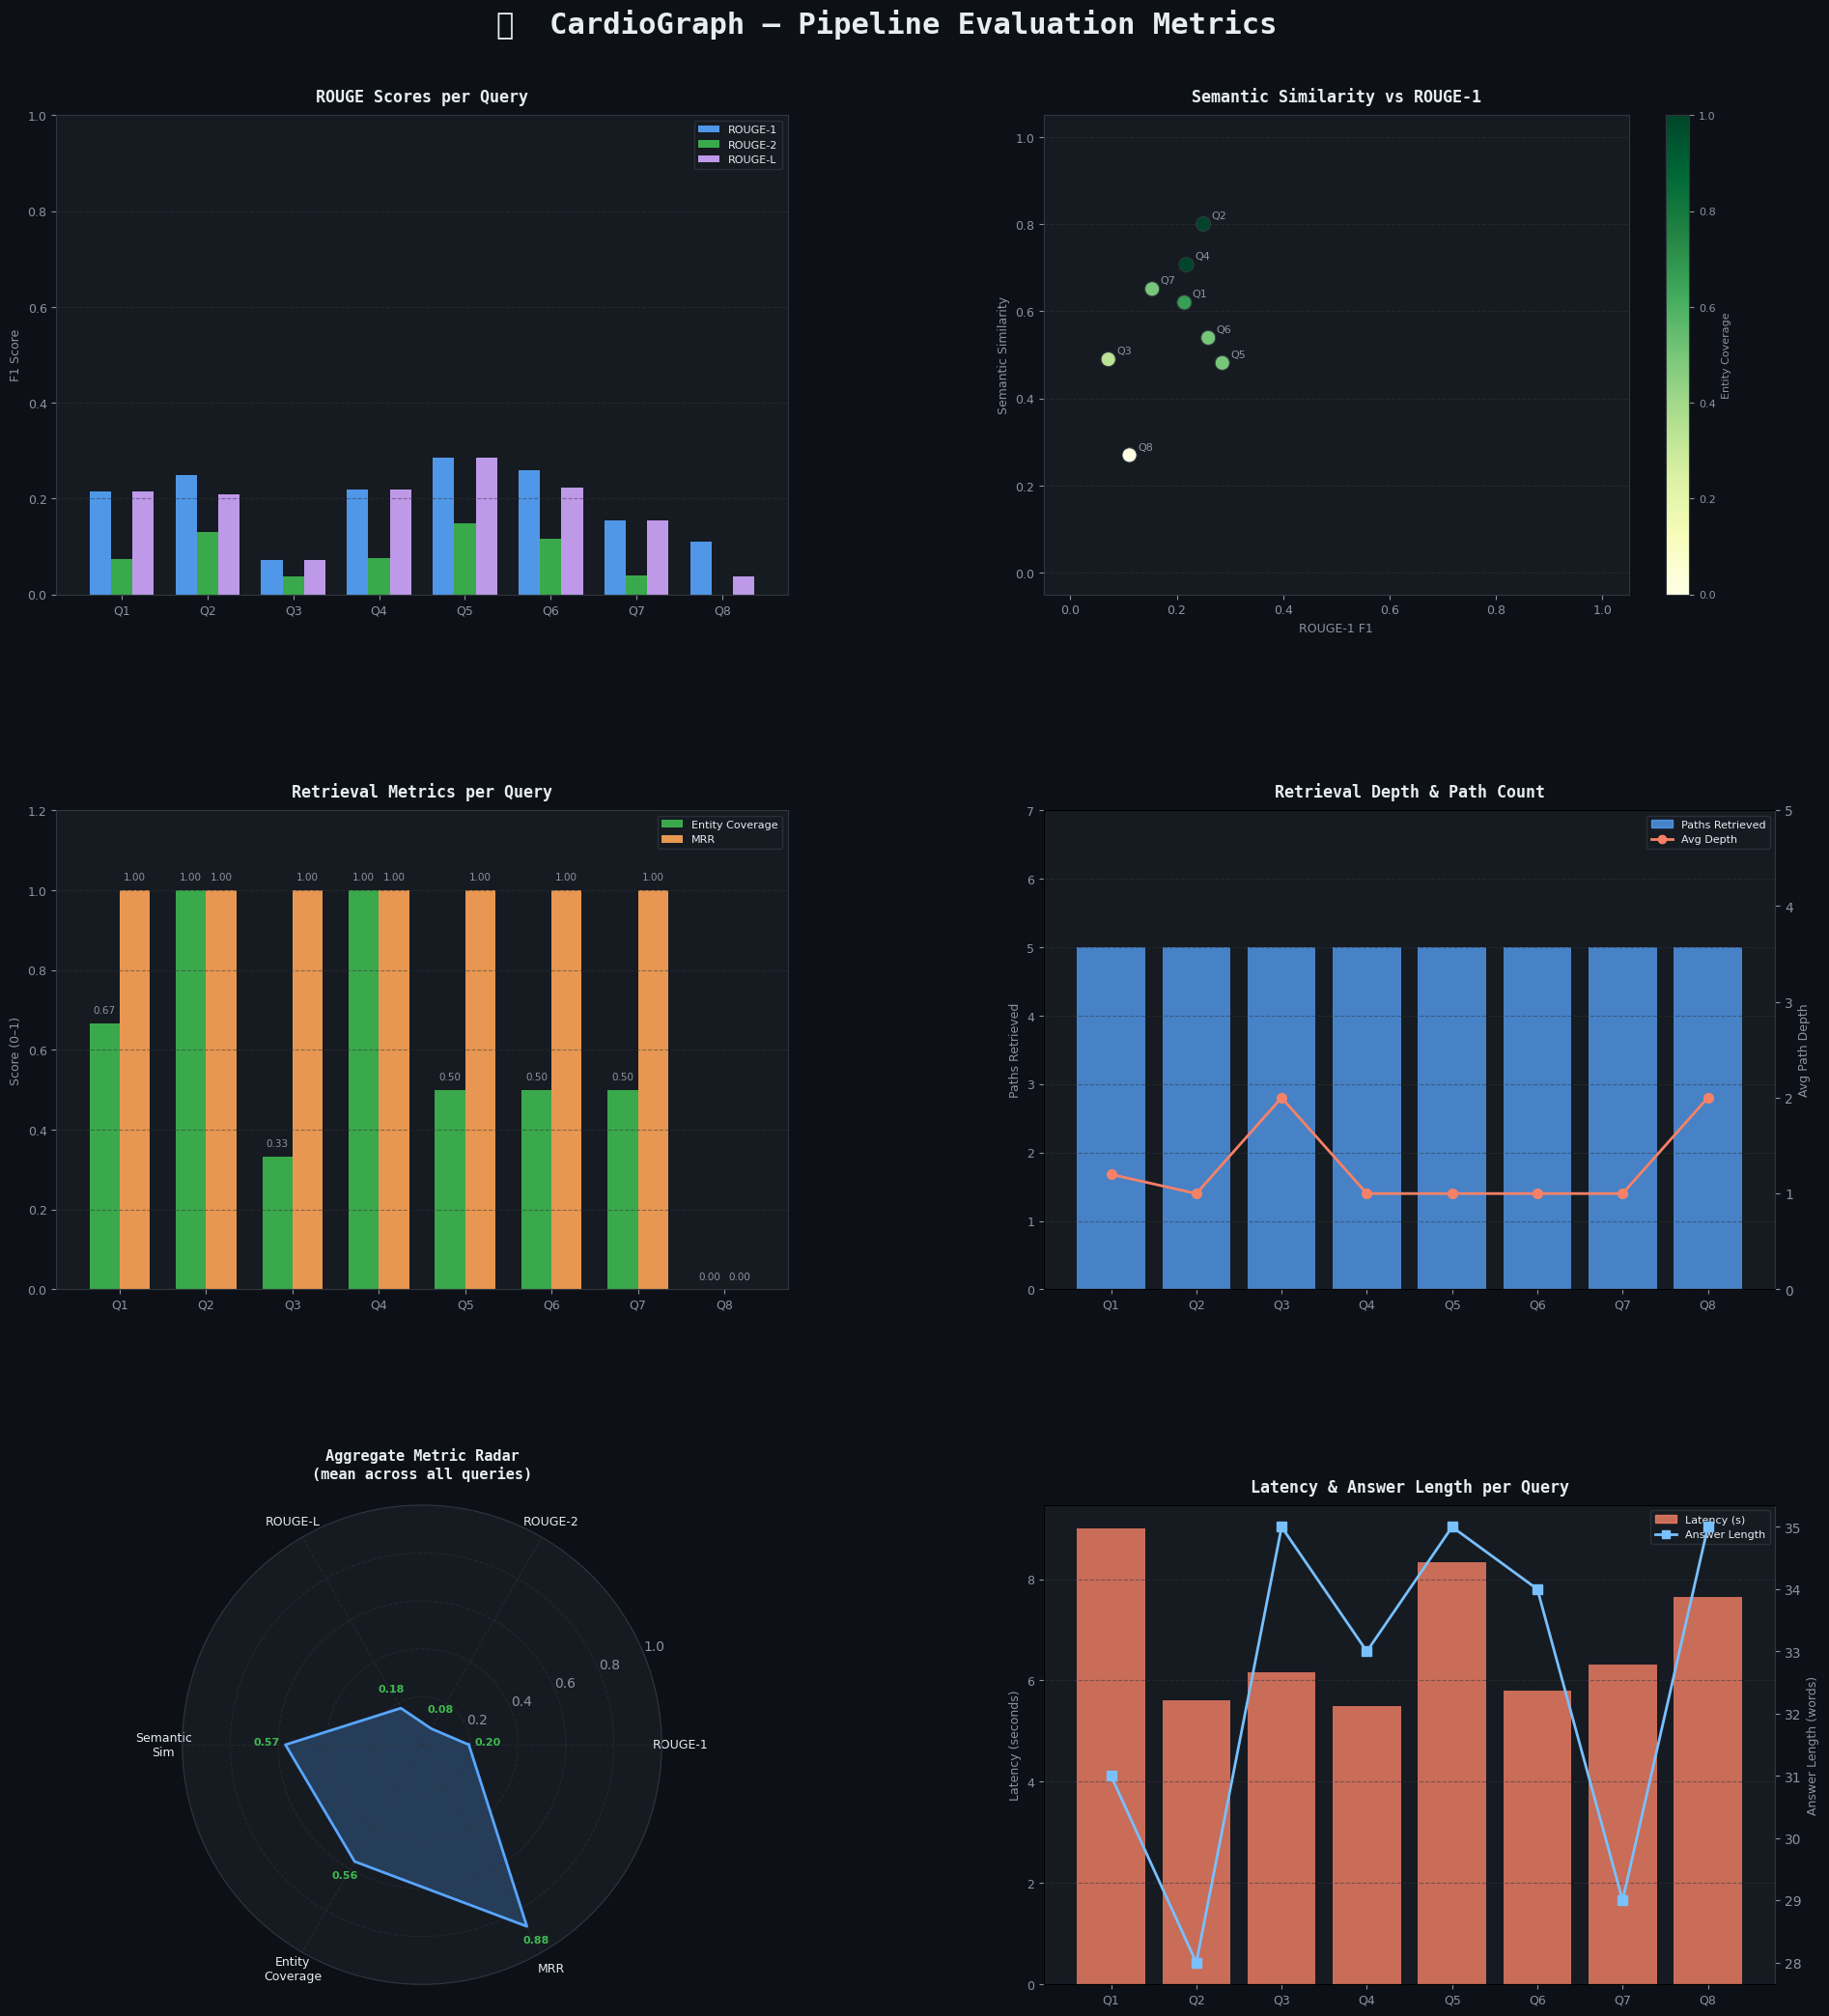


✅ Chart saved to /kaggle/working/cardiograph_metrics.png

PER-QUERY SUMMARY TABLE
    rouge1  rouge2  rougeL  semantic_sim  entity_coverage  mrr  num_paths  elapsed_sec
Q1   0.214   0.074   0.214         0.620            0.667  1.0          5         9.01
Q2   0.250   0.130   0.208         0.800            1.000  1.0          5         5.61
Q3   0.071   0.037   0.071         0.490            0.333  1.0          5         6.17
Q4   0.218   0.076   0.218         0.707            1.000  1.0          5         5.50
Q5   0.286   0.148   0.286         0.481            0.500  1.0          5         8.33
Q6   0.259   0.115   0.222         0.539            0.500  1.0          5         5.79
Q7   0.154   0.040   0.154         0.651            0.500  1.0          5         6.32
Q8   0.111   0.000   0.037         0.270            0.000  0.0          5         7.65

MEAN ACROSS ALL QUERIES
rouge1             0.1955
rouge2             0.0776
rougeL             0.1764
semantic_sim       0.5698
entit

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10c — Metrics Visualization
# Run AFTER Cell 10b. Uses eval_results_df produced there.
# Generates 6 charts saved as cardiograph_metrics.png
# ─────────────────────────────────────────────────────────────────────────────

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── Colour palette ──────────────────────────────────────────────────────────
C = {
    "bg":      "#0d1117",
    "panel":   "#161b22",
    "border":  "#30363d",
    "accent1": "#58a6ff",   # blue
    "accent2": "#3fb950",   # green
    "accent3": "#f78166",   # red/orange
    "accent4": "#d2a8ff",   # purple
    "accent5": "#ffa657",   # amber
    "accent6": "#79c0ff",   # light blue
    "text":    "#e6edf3",
    "subtext": "#8b949e",
}

SHORT_LABELS = [f"Q{i+1}" for i in range(len(eval_results_df))]
N = len(eval_results_df)

fig = plt.figure(figsize=(20, 22), facecolor=C["bg"])
fig.suptitle(
    "🫀  CardioGraph — Pipeline Evaluation Metrics",
    fontsize=22, fontweight="bold", color=C["text"],
    y=0.98, fontfamily="monospace"
)

# Helper: style axes
def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor(C["panel"])
    for spine in ax.spines.values():
        spine.set_edgecolor(C["border"])
    ax.tick_params(colors=C["subtext"], labelsize=9)
    ax.set_title(title, color=C["text"], fontsize=12,
                 fontweight="bold", pad=10, fontfamily="monospace")
    if xlabel: ax.set_xlabel(xlabel, color=C["subtext"], fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=C["subtext"], fontsize=9)
    ax.title.set_color(C["text"])
    ax.xaxis.label.set_color(C["subtext"])
    ax.yaxis.label.set_color(C["subtext"])
    ax.grid(axis="y", color=C["border"], linestyle="--", alpha=0.5)

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.96, top=0.93, bottom=0.05)

# ── Chart 1: ROUGE scores per query (grouped bar) ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(N)
w   = 0.25
ax1.bar(x - w,   eval_results_df["rouge1"], w, label="ROUGE-1", color=C["accent1"], alpha=0.9)
ax1.bar(x,       eval_results_df["rouge2"], w, label="ROUGE-2", color=C["accent2"], alpha=0.9)
ax1.bar(x + w,   eval_results_df["rougeL"], w, label="ROUGE-L", color=C["accent4"], alpha=0.9)
ax1.set_xticks(x); ax1.set_xticklabels(SHORT_LABELS)
ax1.set_ylim(0, 1.0)
ax1.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax1, "ROUGE Scores per Query", ylabel="F1 Score")

# ── Chart 2: Semantic similarity vs ROUGE-1 scatter ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sc  = ax2.scatter(
    eval_results_df["rouge1"],
    eval_results_df["semantic_sim"],
    c=eval_results_df["entity_coverage"],
    cmap="YlGn", s=120, edgecolors=C["border"], linewidths=0.8,
    vmin=0, vmax=1, zorder=3
)
for i, (r, s) in enumerate(zip(eval_results_df["rouge1"],
                                eval_results_df["semantic_sim"])):
    ax2.annotate(SHORT_LABELS[i], (r, s),
                 textcoords="offset points", xytext=(6, 4),
                 color=C["subtext"], fontsize=8)
cb = plt.colorbar(sc, ax=ax2)
cb.set_label("Entity Coverage", color=C["subtext"], fontsize=8)
cb.ax.yaxis.set_tick_params(color=C["subtext"])
plt.setp(cb.ax.yaxis.get_ticklabels(), color=C["subtext"], fontsize=8)
cb.outline.set_edgecolor(C["border"])
ax2.set_xlim(-0.05, 1.05); ax2.set_ylim(-0.05, 1.05)
style_ax(ax2, "Semantic Similarity vs ROUGE-1",
         xlabel="ROUGE-1 F1", ylabel="Semantic Similarity")

# ── Chart 3: Retrieval metrics per query (entity coverage + MRR) ─────────────
ax3 = fig.add_subplot(gs[1, 0])
x   = np.arange(N)
w   = 0.35
b1  = ax3.bar(x - w/2, eval_results_df["entity_coverage"], w,
              label="Entity Coverage", color=C["accent2"], alpha=0.9)
b2  = ax3.bar(x + w/2, eval_results_df["mrr"], w,
              label="MRR", color=C["accent5"], alpha=0.9)
ax3.set_xticks(x); ax3.set_xticklabels(SHORT_LABELS)
ax3.set_ylim(0, 1.2)
# Value labels on bars
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 0.02,
             f"{h:.2f}", ha="center", va="bottom",
             color=C["subtext"], fontsize=7.5)
ax3.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax3, "Retrieval Metrics per Query", ylabel="Score (0–1)")

# ── Chart 4: Paths retrieved + avg depth per query ───────────────────────────
ax4  = fig.add_subplot(gs[1, 1])
ax4b = ax4.twinx()
ax4.bar(SHORT_LABELS, eval_results_df["num_paths"],
        color=C["accent1"], alpha=0.75, label="Paths Retrieved")
ax4b.plot(SHORT_LABELS, eval_results_df["avg_depth"],
          color=C["accent3"], marker="o", linewidth=2,
          markersize=7, label="Avg Depth")
ax4.set_ylim(0, max(eval_results_df["num_paths"]) * 1.4)
ax4b.set_ylim(0, max(eval_results_df["avg_depth"]) * 2.5)
ax4.set_ylabel("Paths Retrieved", color=C["subtext"], fontsize=9)
ax4b.set_ylabel("Avg Path Depth", color=C["subtext"], fontsize=9)
ax4b.tick_params(colors=C["subtext"])
ax4b.spines["right"].set_edgecolor(C["border"])
h1  = mpatches.Patch(color=C["accent1"], alpha=0.75, label="Paths Retrieved")
h2, = ax4b.plot([], [], color=C["accent3"], marker="o",
                linewidth=2, label="Avg Depth")
ax4.legend(handles=[h1, h2], facecolor=C["panel"],
           edgecolor=C["border"], labelcolor=C["text"], fontsize=8)
style_ax(ax4, "Retrieval Depth & Path Count")

# ── Chart 5: Radar chart — aggregate metric overview ─────────────────────────
ax5 = fig.add_subplot(gs[2, 0], polar=True)
categories   = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "Semantic\nSim",
                "Entity\nCoverage", "MRR"]
values_mean  = [
    eval_results_df["rouge1"].mean(),
    eval_results_df["rouge2"].mean(),
    eval_results_df["rougeL"].mean(),
    eval_results_df["semantic_sim"].mean(),
    eval_results_df["entity_coverage"].mean(),
    eval_results_df["mrr"].mean(),
]
values_mean += values_mean[:1]   # close the polygon
angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
angles += angles[:1]

ax5.set_facecolor(C["panel"])
ax5.plot(angles, values_mean, color=C["accent1"], linewidth=2)
ax5.fill(angles, values_mean, color=C["accent1"], alpha=0.25)
ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(categories, color=C["text"], fontsize=9)
ax5.set_ylim(0, 1)
ax5.yaxis.set_tick_params(labelcolor=C["subtext"])
ax5.set_title("Aggregate Metric Radar\n(mean across all queries)",
              color=C["text"], fontsize=11, fontweight="bold",
              pad=20, fontfamily="monospace")
ax5.grid(color=C["border"], linestyle="--", alpha=0.5)
ax5.spines["polar"].set_edgecolor(C["border"])

# Annotate radar values
for angle, val, cat in zip(angles[:-1], values_mean[:-1], categories):
    ax5.annotate(f"{val:.2f}",
                 xy=(angle, val),
                 xytext=(angle, val + 0.08),
                 color=C["accent2"], fontsize=8, ha="center",
                 fontweight="bold")

# ── Chart 6: Latency + answer length per query ───────────────────────────────
ax6  = fig.add_subplot(gs[2, 1])
ax6b = ax6.twinx()
ax6.bar(SHORT_LABELS, eval_results_df["elapsed_sec"],
        color=C["accent3"], alpha=0.8, label="Latency (s)")
ax6b.plot(SHORT_LABELS, eval_results_df["answer_length"],
          color=C["accent6"], marker="s", linewidth=2,
          markersize=7, label="Answer Length (words)")
ax6.set_ylabel("Latency (seconds)", color=C["subtext"], fontsize=9)
ax6b.set_ylabel("Answer Length (words)", color=C["subtext"], fontsize=9)
ax6b.tick_params(colors=C["subtext"])
ax6b.spines["right"].set_edgecolor(C["border"])
h3  = mpatches.Patch(color=C["accent3"], alpha=0.8, label="Latency (s)")
h4, = ax6b.plot([], [], color=C["accent6"], marker="s",
                linewidth=2, label="Answer Length")
ax6.legend(handles=[h3, h4], facecolor=C["panel"],
           edgecolor=C["border"], labelcolor=C["text"], fontsize=8)
style_ax(ax6, "Latency & Answer Length per Query")

# ─── Save ─────────────────────────────────────────────────────────────────────
out_path = "/kaggle/working/cardiograph_metrics.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print(f"\n✅ Chart saved to {out_path}")

# ─── Print clean summary table ────────────────────────────────────────────────
print("\n" + "=" * 65)
print("PER-QUERY SUMMARY TABLE")
print("=" * 65)
display_cols = ["rouge1", "rouge2", "rougeL", "semantic_sim",
                "entity_coverage", "mrr", "num_paths", "elapsed_sec"]
summary = eval_results_df[display_cols].copy()
summary.index = SHORT_LABELS
print(summary.round(3).to_string())

print("\n" + "=" * 65)
print("MEAN ACROSS ALL QUERIES")
print("=" * 65)
print(summary.mean().round(4).to_string())


In [39]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

Free GPU: 8.09 GB


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10d — 30 Complex Queries loaded from CSV
#
# Expected CSV format (save as cardiograph_queries.csv):
#
# id,type,query,expected_entities,reference_answer
# Q01,multi-symptom,"I have chest pain and fatigue...","['chest pain','heart failure']","Yes. Chest pain..."
# Q02,drug-interaction,"Can aspirin and warfarin be combined?","['aspirin','warfarin']","Combining aspirin..."
#
# Columns:
#   id                : unique query ID (e.g. Q01, Q02 ...)
#   type              : multi-symptom | drug-interaction | risk-chain | diagnostic
#   query             : the patient question string
#   expected_entities : Python list as string e.g. "['hypertension','chest pain']"
#   reference_answer  : ground truth answer string
#
# ─────────────────────────────────────────────────────────────────────────────

import ast
import time
import pandas as pd
from rouge_score import rouge_scorer as rs_module

# ── Step 1: Load queries from CSV ─────────────────────────────────────────────
QUERIES_CSV_PATH = "/kaggle/input/datasets/pakyalakshmi/cardiograph-queries/cardiograph_queries.csv"
# ↑ Update this path to wherever you uploaded the CSV on Kaggle

print(f"Loading queries from: {QUERIES_CSV_PATH}")
queries_raw = pd.read_csv(QUERIES_CSV_PATH)
queries_raw.columns = queries_raw.columns.str.strip().str.lower()

# ── Validate required columns ─────────────────────────────────────────────────
REQUIRED_COLS = {"id", "type", "query", "expected_entities", "reference_answer"}
missing = REQUIRED_COLS - set(queries_raw.columns)
assert not missing, f"❌ Missing columns in CSV: {missing}"
print(f"  Loaded {len(queries_raw):,} queries.")
print(f"  Columns: {list(queries_raw.columns)}")

# ── Step 2: Parse expected_entities from string → list ────────────────────────
def parse_entity_list(val):
    """
    Safely parse expected_entities column.
    Handles:
      - Python list strings:  "['hypertension', 'chest pain']"
      - Comma-separated:       "hypertension, chest pain"
      - Already a list:        ['hypertension', 'chest pain']
    """
    if isinstance(val, list):
        return [str(v).strip().lower() for v in val if v]
    if pd.isna(val) or str(val).strip() == "":
        return []
    val = str(val).strip()
    # Try literal eval first (handles "['a', 'b']" format)
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [str(v).strip().lower() for v in parsed if v]
    except Exception:
        pass
    # Fallback: comma-split
    return [v.strip().strip("'\"").lower() for v in val.split(",") if v.strip()]

queries_raw["expected_entities"] = queries_raw["expected_entities"].apply(parse_entity_list)
queries_raw["reference_answer"]  = queries_raw["reference_answer"].fillna("").str.strip()
queries_raw["id"]                = queries_raw["id"].astype(str).str.strip()
queries_raw["type"]              = queries_raw["type"].astype(str).str.strip()
queries_raw["query"]             = queries_raw["query"].astype(str).str.strip()

# ── Step 3: Convert to list of dicts (same format as before) ──────────────────
COMPLEX_QA_DATASET = queries_raw.to_dict(orient="records")

# ── Preview loaded queries ────────────────────────────────────────────────────
print(f"\nQuery type breakdown:")
print(queries_raw["type"].value_counts().to_string())
print(f"\nSample queries:")
for row in COMPLEX_QA_DATASET[:3]:
    print(f"  [{row['id']}] ({row['type']}) {row['query'][:70]}...")
    print(f"         Expected: {row['expected_entities']}")

# ── Step 4: Per-Query Full Pipeline Runner (unchanged) ────────────────────────
def run_and_display_query(sample: dict, idx: int, total: int) -> dict:
    qid   = sample["id"]
    qtype = sample["type"]
    query = sample["query"]
    expected  = sample["expected_entities"]
    reference = sample["reference_answer"]

    print(f"\n{'█' * 65}")
    print(f"  {qid} [{idx}/{total}]  [{qtype.upper()}]")
    print(f"{'█' * 65}")
    print(f"  Query: {query}")

    t0 = time.time()

    # ── 1. Task Parsing ───────────────────────────────────────────────────────
    print(f"\n  ┌─ [1] TASK PARSING {'─'*44}")
    try:
        parsed = parse_task(query)
    except Exception as e:
        print(f"  │  ⚠️  Parse failed: {e}")
        parsed = {"entities": expected, "sub_questions": [], "context": []}

    print(f"  │  Entities : {parsed.get('entities', [])}")
    for sq in parsed.get("sub_questions", []):
        print(f"  │  Sub-Q    : {sq}")
    for ctx in parsed.get("context", []):
        print(f"  │  Context  : {ctx}")

    # ── 2. Entity Matching ────────────────────────────────────────────────────
    print(f"  ├─ [2] ENTITY MATCHING {'─'*40}")
    matched = matcher.match_all(parsed.get("entities", expected))
    for ent, matches in matched.items():
        if matches:
            top = matches[0]
            print(f"  │  '{ent}' → '{top['term']}' "
                  f"(type={top['type']}, score={top['score']:.4f})")
        else:
            print(f"  │  '{ent}' → ❌ no match")

    # ── 3. Reasoning Paths ───────────────────────────────────────────────────
    print(f"  ├─ [3] REASONING PATHS {'─'*40}")
    paths = retriever.retrieve(matched, query)
    if paths:
        for i, p in enumerate(paths, 1):
            path_str = " → ".join([
                f"{n} [{r}]" if r else n
                for n, r in p["path"]
            ])
            print(f"  │  Path {i} (score={p['score']:.4f}): {path_str}")
    else:
        print(f"  │  ❌ No paths retrieved")

    # ── 4. Context + Answer ───────────────────────────────────────────────────
    context = build_context(paths)
    print(f"  ├─ [4] GENERATED ANSWER {'─'*39}")
    try:
        answer = generate_answer(query, parsed, context)
    except Exception as e:
        print(f"  │  ⚠️  Answer gen failed: {e}")
        answer = context
    answer_display = answer if len(answer) < 500 else answer[:500] + "..."
    for line in answer_display.split("\n"):
        if line.strip():
            print(f"  │  {line.strip()}")

    # ── 5. Claim Verification ─────────────────────────────────────────────────
    print(f"  └─ [5] CLAIM VERIFICATION {'─'*37}")
    try:
        verification = verify_claims(answer, graph_db, embed_model)
    except Exception as e:
        verification = []
        print(f"     ⚠️  Verification failed: {e}")
    for v in verification:
        icon = {"Supported": "✅", "Uncertain": "⚠️",
                "Contradicted": "❌"}.get(v["label"], "❓")
        claim_display = (v["claim"][:100] + "..."
                         if len(v["claim"]) > 100 else v["claim"])
        print(f"     {icon} [{v['label']:12s}] {claim_display}")

    elapsed = round(time.time() - t0, 2)

    # ── Metrics ───────────────────────────────────────────────────────────────
    rouge_obj  = rs_module.RougeScorer(["rouge1", "rouge2", "rougeL"],
                                        use_stemmer=True)
    rouge      = rouge_obj.score(reference, answer)
    entity_cov = compute_entity_coverage(paths, expected)
    mrr        = compute_mrr(paths, expected)
    sem_sim    = compute_semantic_similarity(answer, reference, embed_model)

    print(f"\n  📊 METRICS  EntityCov={entity_cov:.2f}  MRR={mrr:.2f}  "
          f"R1={rouge['rouge1'].fmeasure:.3f}  "
          f"SemSim={sem_sim:.3f}  ({elapsed}s)")

    return {
        "id":              qid,
        "type":            qtype,
        "query":           query,
        "parsed":          parsed,
        "matched":         matched,
        "num_paths":       len(paths),
        "avg_depth":       compute_avg_path_depth(paths),
        "entity_coverage": entity_cov,
        "mrr":             mrr,
        "rouge1":          rouge["rouge1"].fmeasure,
        "rouge2":          rouge["rouge2"].fmeasure,
        "rougeL":          rouge["rougeL"].fmeasure,
        "semantic_sim":    sem_sim,
        "answer_length":   compute_answer_length(answer),
        "elapsed_sec":     elapsed,
        "answer":          answer,
        "context":         context,
        "paths":           paths,
        "verification":    verification,
    }


# ── Step 5: Run all queries ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"🫀 CARDIOGRAPH — {len(COMPLEX_QA_DATASET)} QUERY EVALUATION")
print("=" * 65)

complex_eval_records = []
for i, sample in enumerate(COMPLEX_QA_DATASET, 1):
    record = run_and_display_query(sample, i, len(COMPLEX_QA_DATASET))
    complex_eval_records.append(record)

complex_eval_df = pd.DataFrame(complex_eval_records)

# ── Aggregate results ─────────────────────────────────────────────────────────
print(f"\n\n{'=' * 65}")
print("AGGREGATE METRICS BY QUERY TYPE")
print("=" * 65)
type_summary = complex_eval_df.groupby("type")[[
    "entity_coverage", "mrr", "rouge1", "rouge2",
    "rougeL", "semantic_sim", "elapsed_sec"
]].mean().round(4)
print(type_summary.to_string())

print(f"\n{'=' * 65}")
print(f"OVERALL AGGREGATE ({len(COMPLEX_QA_DATASET)} queries)")
print("=" * 65)
print(complex_eval_df[[
    "entity_coverage", "mrr", "rouge1", "rouge2",
    "rougeL", "semantic_sim", "elapsed_sec"
]].mean().round(4).to_string())

print("\n✅ complex_eval_df ready for Cell 10e (baseline comparison).")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading queries from: /kaggle/input/datasets/pakyalakshmi/cardiograph-queries/cardiograph_queries.csv
  Loaded 30 queries.
  Columns: ['id', 'type', 'query', 'expected_entities', 'reference_answer']

Query type breakdown:
type
multi-symptom       8
risk-chain          8
drug-interaction    7
diagnostic          7

Sample queries:
  [Q01] (multi-symptom) I have chest pain, fatigue, and swollen legs. Could this be heart fail...
         Expected: ['chest pain', 'heart failure', 'edema', 'fatigue']
  [Q02] (multi-symptom) I feel dizzy, short of breath, and my heart is racing. What could be w...
         Expected: ['tachycardia', 'dyspnea', 'arrhythmia']
  [Q03] (multi-symptom) I have high BP, high cholesterol and I am obese. What cardiovascular d...
         Expected: ['hypertension', 'hyperlipidemia', 'obesity', 'coronary artery disease']

🫀 CARDIOGRAPH — 30 QUERY EVALUATION

█████████████████████████████████████████████████████████████████
  Q01 [1/30]  [MULTI-SYMPTOM]
█████████████████

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  │  Path 1 (score=2.0343): chest pain → coronary disease [INDICATES]
  │  Path 2 (score=2.0343): chest pain → esophageal diseases [INDICATES]
  │  Path 3 (score=2.0343): chest pain → myocardial infarction [INDICATES]
  │  Path 4 (score=2.0343): chest pain → esophageal motility disorders [INDICATES]
  │  Path 5 (score=1.9895): heart failure → ventricular pressure [HAS_SYMPTOM] → myocardial contusions [INDICATES]
  ├─ [4] GENERATED ANSWER ───────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

     ✅ [Supported   ] Clinical Risk (Severity of a heart valve problem): The severity of a heart valve problem is typicall...

  📊 METRICS  EntityCov=0.50  MRR=0.50  R1=0.127  SemSim=0.582  (25.18s)

█████████████████████████████████████████████████████████████████
  Q30 [30/30]  [DIAGNOSTIC]
█████████████████████████████████████████████████████████████████
  Query: What is the difference between a stress test and a coronary angiogram and when is each used?

  ┌─ [1] TASK PARSING ────────────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  │  Entities : ['stress test', 'coronary angiogram']
  │  Sub-Q    : Describe the differences between a stress test and a coronary angiogram.
  │  Sub-Q    : In what situations is a stress test typically used?
  │  Sub-Q    : In what situations is a coronary angiogram typically used?
  ├─ [2] ENTITY MATCHING ────────────────────────────────────────
  │  'stress test' → 'dental stress analysis' (type=technique, score=0.5866)
  │  'coronary angiogram' → 'coronary angiography' (type=technique, score=0.8633)
  ├─ [3] REASONING PATHS ────────────────────────────────────────
  │  ❌ No paths retrieved
  ├─ [4] GENERATED ANSWER ───────────────────────────────────────


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  │  I'm sorry for any inconvenience, but the provided knowledge context does not contain sufficient information to answer your questions about the differences between a stress test and a coronary angiogram, or the typical situations where each might be used.
  │  Here's a general explanation based on common medical practice:
  │  1. Differences between a stress test and a coronary angiogram:
  │  - A stress test (also known as exercise stress testing) is a non-invasive test that checks your heart's response t...
  └─ [5] CLAIM VERIFICATION ─────────────────────────────────────
     ✅ [Supported   ] I'm sorry for any inconvenience, but the provided knowledge context does not contain sufficient info...

  📊 METRICS  EntityCov=0.00  MRR=0.00  R1=0.136  SemSim=0.752  (50.37s)


AGGREGATE METRICS BY QUERY TYPE
                  entity_coverage     mrr  rouge1  rouge2  rougeL  semantic_sim  elapsed_sec
type                                                                                     

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10e — Baseline Comparison
# Runs 3 baselines on the same 30 queries and computes identical metrics
#
# Baseline A: LLM answer with NO graph context (raw query only)
# Baseline B: LLM answer with only top-1 MeSH match as context
# Baseline C: Random path retrieval (no scoring — random edge walk)
# CardioGraph: Full pipeline (already in complex_eval_df)
# ─────────────────────────────────────────────────────────────────────────────

import random
import time
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer as rs_module


# ── Baseline A: LLM with NO graph ────────────────────────────────────────────
BASELINE_A_PROMPT = """<s>[INST] You are a medical assistant.
Answer the following patient question as accurately as possible.

Question: {query}

Provide a concise medical answer. [/INST]"""


def baseline_a_answer(query: str) -> str:
    """LLM answer with zero graph context."""
    prompt = BASELINE_A_PROMPT.format(query=query)
    raw    = llm_pipe(prompt)[0]["generated_text"]
    if "[/INST]" in raw:
        return raw.split("[/INST]")[-1].strip()
    return raw[len(prompt):].strip()


# ── Baseline B: LLM with top-1 MeSH match only ───────────────────────────────
BASELINE_B_PROMPT = """<s>[INST] You are a medical assistant.
Answer the following patient question using ONLY the provided medical term context.

Question: {query}

Context: The primary medical concept identified is: {mesh_term} (type: {mesh_type}).

Provide a concise medical answer grounded in this context. [/INST]"""


def baseline_b_answer(query: str, matched: dict) -> str:
    """LLM answer with only top-1 MeSH term as context."""
    # Find the highest-scoring matched term
    best_term, best_type = "unknown", "unknown"
    best_score = -1
    for entity, matches in matched.items():
        if matches and matches[0]["score"] > best_score:
            best_score = matches[0]["score"]
            best_term  = matches[0]["term"]
            best_type  = matches[0]["type"]

    prompt = BASELINE_B_PROMPT.format(
        query=query, mesh_term=best_term, mesh_type=best_type
    )
    raw = llm_pipe(prompt)[0]["generated_text"]
    if "[/INST]" in raw:
        return raw.split("[/INST]")[-1].strip()
    return raw[len(prompt):].strip()


# ── Baseline C: Random path retrieval ────────────────────────────────────────
def baseline_c_retrieve(matched: dict, n_paths: int = 5) -> list:
    """
    Random graph walk — ignores scoring entirely.
    Picks a random start node from matched entities, then walks randomly.
    """
    random_paths = []

    for entity, matches in matched.items():
        if not matches:
            continue
        start_node = matches[0]["term"]
        start_type = matches[0]["type"]

        # Random BFS — no scoring, random neighbor selection
        with graph_db.driver.session() as session:
            # Get all neighbors regardless of weight
            label = graph_db._label_for_type(start_type)
            rows  = session.run(
                f"""
                MATCH (a:{label} {{name: $name}})-[r]->(b)
                RETURN b.name AS neighbor, b.type AS n_type,
                       type(r) AS relation
                LIMIT 20
                """,
                name=start_node
            ).data()

        if not rows:
            continue

        # Randomly select up to n_paths neighbors
        selected = random.sample(rows, min(n_paths, len(rows)))
        for nbr in selected:
            random_paths.append({
                "source_entity": entity,
                "path": [
                    (start_node, None),
                    (nbr["neighbor"], nbr["relation"])
                ],
                "score": random.uniform(0.1, 0.9),  # random score
                "depth": 1,
            })

    random.shuffle(random_paths)
    return random_paths[:n_paths]


def baseline_c_answer(query: str, parsed: dict, matched: dict) -> str:
    """LLM answer using randomly retrieved paths as context."""
    random_paths = baseline_c_retrieve(matched)
    context      = build_context(random_paths)
    if not context or context == "No relevant knowledge paths found.":
        context  = "No relevant paths found via random retrieval."
    return generate_answer(query, parsed, context)


# ── Metric helper ─────────────────────────────────────────────────────────────
def score_answer(answer: str, reference: str, paths: list,
                 expected_entities: list) -> dict:
    rouge_obj  = rs_module.RougeScorer(["rouge1", "rouge2", "rougeL"],
                                        use_stemmer=True)
    rouge      = rouge_obj.score(reference, answer)
    return {
        "rouge1":          round(rouge["rouge1"].fmeasure, 4),
        "rouge2":          round(rouge["rouge2"].fmeasure, 4),
        "rougeL":          round(rouge["rougeL"].fmeasure, 4),
        "semantic_sim":    compute_semantic_similarity(answer, reference, embed_model),
        "entity_coverage": compute_entity_coverage(paths, expected_entities),
        "mrr":             compute_mrr(paths, expected_entities),
        "answer_length":   compute_answer_length(answer),
    }


# ── Run baselines on all 30 queries ───────────────────────────────────────────
print("=" * 65)
print("🔬 BASELINE COMPARISON — 3 Baselines vs CardioGraph")
print("=" * 65)
print("Running on 30 queries. This will take a while (3 LLM calls per query)...")

baseline_records = {
    "baseline_a": [],
    "baseline_b": [],
    "baseline_c": [],
}

for i, sample in enumerate(COMPLEX_QA_DATASET, 1):
    query    = sample["query"]
    expected = sample["expected_entities"]
    ref      = sample["reference_answer"]
    qid      = sample["id"]

    print(f"\n[{i:02d}/30] {qid}: {query[:60]}...")

        # NEW — safer lookup with fallback
    row_match = complex_eval_df[complex_eval_df["id"] == qid]
    if len(row_match) == 0:
        print(f"  ⚠️  {qid} not found in complex_eval_df, skipping.")
        continue
    parsed  = row_match["parsed"].values[0]
    matched = matcher.match_all(parsed.get("entities", expected))

    # ── Baseline A ──────────────────────────────────────────────────────────
    t0 = time.time()
    ans_a = baseline_a_answer(query)
    metrics_a = score_answer(ans_a, ref, [], expected)
    metrics_a.update({"id": qid, "type": sample["type"],
                      "elapsed_sec": round(time.time() - t0, 2),
                      "answer": ans_a})
    baseline_records["baseline_a"].append(metrics_a)
    print(f"  A (no graph): R1={metrics_a['rouge1']:.3f}  "
          f"SemSim={metrics_a['semantic_sim']:.3f}")

    # ── Baseline B ──────────────────────────────────────────────────────────
    t0 = time.time()
    ans_b = baseline_b_answer(query, matched)
    metrics_b = score_answer(ans_b, ref, [], expected)
    metrics_b.update({"id": qid, "type": sample["type"],
                      "elapsed_sec": round(time.time() - t0, 2),
                      "answer": ans_b})
    baseline_records["baseline_b"].append(metrics_b)
    print(f"  B (top-1 MeSH): R1={metrics_b['rouge1']:.3f}  "
          f"SemSim={metrics_b['semantic_sim']:.3f}")

    # ── Baseline C ──────────────────────────────────────────────────────────
    t0 = time.time()
    ans_c = baseline_c_answer(query, parsed, matched)
    rand_paths = baseline_c_retrieve(matched)
    metrics_c = score_answer(ans_c, ref, rand_paths, expected)
    metrics_c.update({"id": qid, "type": sample["type"],
                      "elapsed_sec": round(time.time() - t0, 2),
                      "answer": ans_c})
    baseline_records["baseline_c"].append(metrics_c)
    print(f"  C (random paths): R1={metrics_c['rouge1']:.3f}  "
          f"SemSim={metrics_c['semantic_sim']:.3f}")

# ── Build comparison dataframes ───────────────────────────────────────────────
baseline_a_df = pd.DataFrame(baseline_records["baseline_a"])
baseline_b_df = pd.DataFrame(baseline_records["baseline_b"])
baseline_c_df = pd.DataFrame(baseline_records["baseline_c"])

METRIC_COLS = ["rouge1", "rouge2", "rougeL", "semantic_sim",
               "entity_coverage", "mrr", "elapsed_sec"]

# ── Final comparison table ────────────────────────────────────────────────────
comparison_summary = pd.DataFrame({
    "Baseline A (No Graph)":   baseline_a_df[METRIC_COLS].mean(),
    "Baseline B (Top-1 MeSH)": baseline_b_df[METRIC_COLS].mean(),
    "Baseline C (Random Path)": baseline_c_df[METRIC_COLS].mean(),
    "CardioGraph (Full)":      complex_eval_df[METRIC_COLS].mean(),
}).round(4)

print(f"\n\n{'=' * 65}")
print("FINAL COMPARISON TABLE (mean across 30 queries)")
print("=" * 65)
print(comparison_summary.to_string())

# Compute improvement of CardioGraph over each baseline
print(f"\n{'=' * 65}")
print("CARDIOGRAPH IMPROVEMENT OVER BASELINES")
print("=" * 65)
for col in ["rouge1", "rouge2", "semantic_sim", "entity_coverage", "mrr"]:
    cg   = comparison_summary.loc[col, "CardioGraph (Full)"]
    ba   = comparison_summary.loc[col, "Baseline A (No Graph)"]
    bb   = comparison_summary.loc[col, "Baseline B (Top-1 MeSH)"]
    bc   = comparison_summary.loc[col, "Baseline C (Random Path)"]
    print(f"  {col:<20s}: vs A={cg-ba:+.4f}  vs B={cg-bb:+.4f}  vs C={cg-bc:+.4f}")

print("\n✅ baseline_a_df, baseline_b_df, baseline_c_df ready for chart cell.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔬 BASELINE COMPARISON — 3 Baselines vs CardioGraph
Running on 30 queries. This will take a while (3 LLM calls per query)...

[01/30] Q01: I have chest pain, fatigue, and swollen legs. Could this be ...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  A (no graph): R1=0.248  SemSim=0.743
  B (top-1 MeSH): R1=0.316  SemSim=0.802


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  C (random paths): R1=0.089  SemSim=0.691

[30/30] Q30: What is the difference between a stress test and a coronary ...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  A (no graph): R1=0.179  SemSim=0.795
  B (top-1 MeSH): R1=0.179  SemSim=0.814


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  C (random paths): R1=0.132  SemSim=0.759


FINAL COMPARISON TABLE (mean across 30 queries)
                 Baseline A (No Graph)  Baseline B (Top-1 MeSH)  Baseline C (Random Path)  CardioGraph (Full)
rouge1                          0.1892                   0.2556                    0.1821              0.1922
rouge2                          0.0459                   0.0631                    0.0464              0.0490
rougeL                          0.1328                   0.1823                    0.1306              0.1330
semantic_sim                    0.6926                   0.7395                    0.6912              0.6876
entity_coverage                 0.0000                   0.0000                    0.3583              0.4333
mrr                             0.0000                   0.0000                    0.6667              0.6611
elapsed_sec                    12.4517                   8.1400                   12.7027             27.9320

CARDIOGRAPH IMPROVEMENT OV

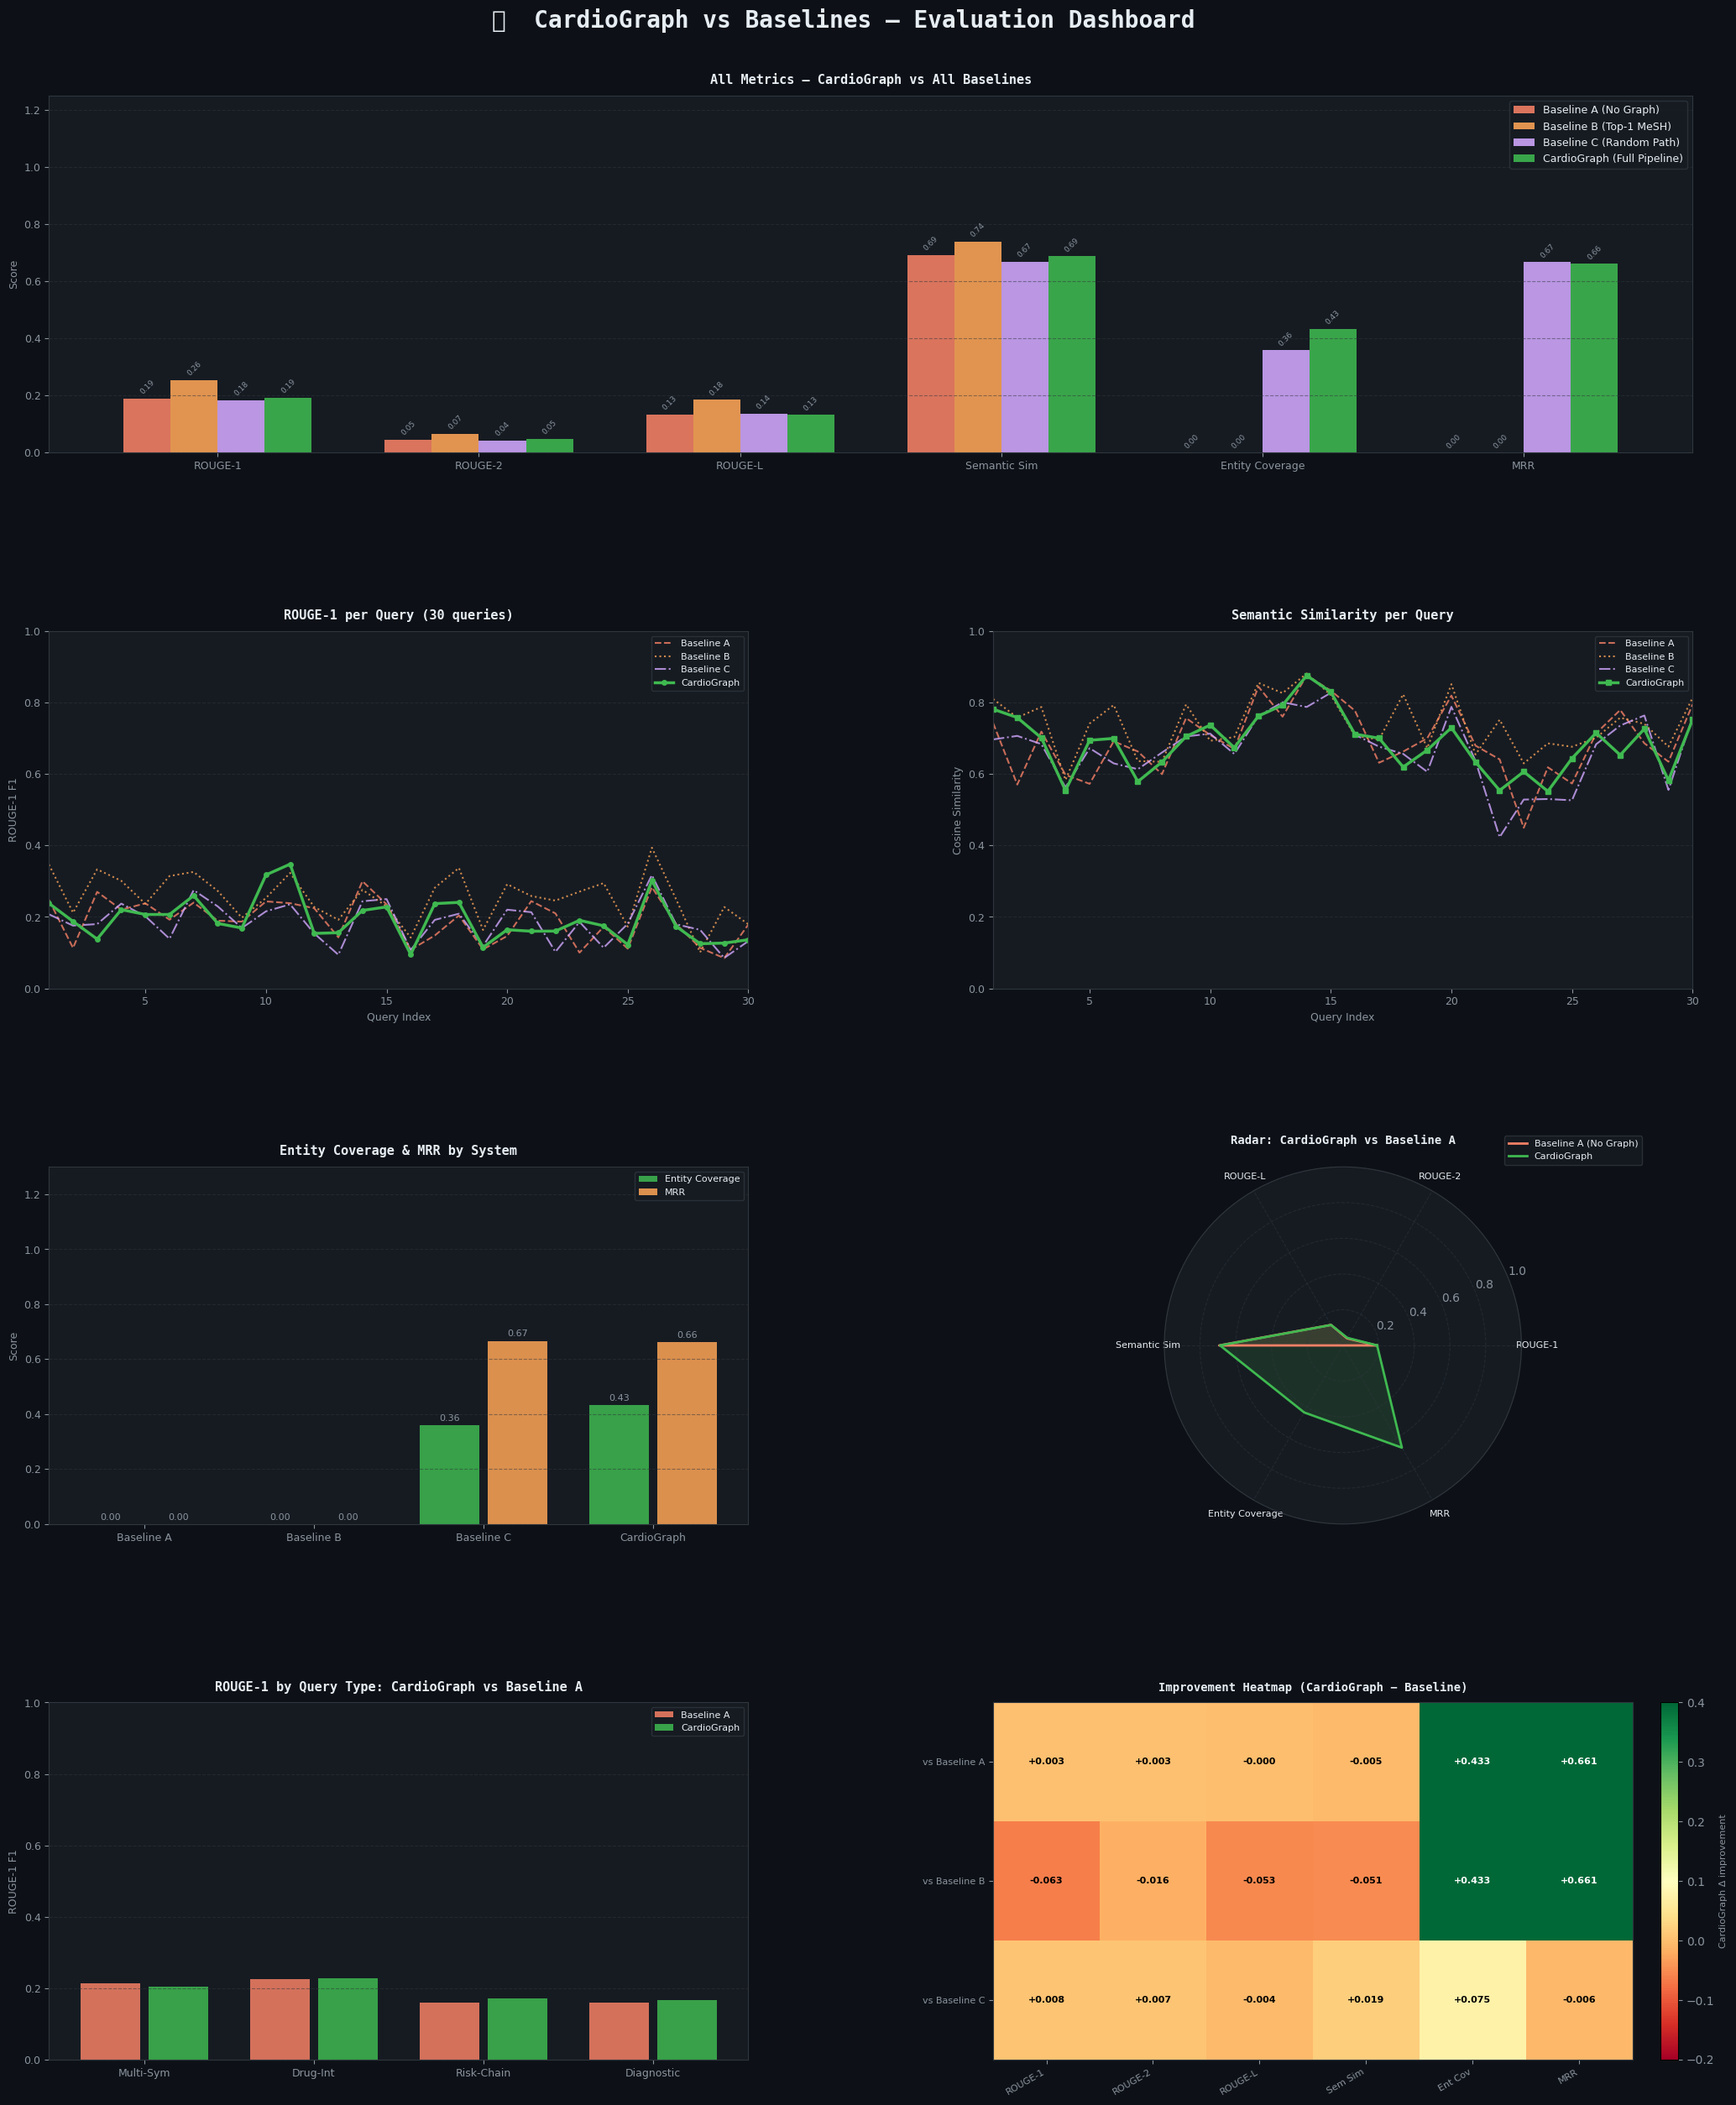


✅ Chart saved to /kaggle/working/cardiograph_baseline_comparison.png


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10f — Baseline vs CardioGraph Visualization
# Generates 7-panel comparison dashboard
# Run after Cell 10e
# ─────────────────────────────────────────────────────────────────────────────

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display

# ── Palette ───────────────────────────────────────────────────────────────────
C = {
    "bg":      "#0d1117",
    "panel":   "#161b22",
    "border":  "#30363d",
    "text":    "#e6edf3",
    "subtext": "#8b949e",
    "A":       "#f78166",   # red-orange — Baseline A
    "B":       "#ffa657",   # amber      — Baseline B
    "Cr":      "#d2a8ff",   # purple     — Baseline C
    "CG":      "#3fb950",   # green      — CardioGraph
}

SYSTEMS  = ["Baseline A\n(No Graph)", "Baseline B\n(Top-1 MeSH)",
            "Baseline C\n(Random Path)", "CardioGraph\n(Full Pipeline)"]
COLORS   = [C["A"], C["B"], C["Cr"], C["CG"]]
METRICS  = ["rouge1", "rouge2", "rougeL", "semantic_sim",
            "entity_coverage", "mrr"]
METRIC_LABELS = ["ROUGE-1", "ROUGE-2", "ROUGE-L",
                 "Semantic Sim", "Entity Coverage", "MRR"]

# Mean values for each system
means = {
    "A":  baseline_a_df[METRICS].mean().values,
    "B":  baseline_b_df[METRICS].mean().values,
    "C":  baseline_c_df[METRICS].mean().values,
    "CG": complex_eval_df[METRICS].mean().values,
}


def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor(C["panel"])
    for spine in ax.spines.values():
        spine.set_edgecolor(C["border"])
    ax.tick_params(colors=C["subtext"], labelsize=9)
    ax.set_title(title, color=C["text"], fontsize=11,
                 fontweight="bold", pad=10, fontfamily="monospace")
    if xlabel: ax.set_xlabel(xlabel, color=C["subtext"], fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=C["subtext"], fontsize=9)
    ax.grid(axis="y", color=C["border"], linestyle="--", alpha=0.5)


fig = plt.figure(figsize=(22, 26), facecolor=C["bg"])
n_queries = len(complex_eval_df)
fig.suptitle("🫀  CardioGraph vs Baselines — Evaluation Dashboard",
             fontsize=20, fontweight="bold", color=C["text"],
             y=0.98, fontfamily="monospace")

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35,
                       left=0.07, right=0.96, top=0.94, bottom=0.04)

# ── Chart 1: Grouped bar — all metrics side by side ──────────────────────────
ax1  = fig.add_subplot(gs[0, :])   # full width
x    = np.arange(len(METRIC_LABELS))
w    = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
for j, (key, color, label) in enumerate(zip(
        ["A","B","C","CG"], COLORS, SYSTEMS)):
    bars = ax1.bar(x + offsets[j], means[key], w,
                   label=label.replace("\n", " "),
                   color=color, alpha=0.88)
    # Value labels
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.2f}", ha="center", va="bottom",
                 color=C["subtext"], fontsize=6.5, rotation=45)

ax1.set_xticks(x)
ax1.set_xticklabels(METRIC_LABELS, color=C["text"], fontsize=10)
ax1.set_ylim(0, 1.25)
ax1.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=9, loc="upper right")
style_ax(ax1, "All Metrics — CardioGraph vs All Baselines", ylabel="Score")

# ── Chart 2: ROUGE comparison line chart across 30 queries ───────────────────
ax2 = fig.add_subplot(gs[1, 0])
qids = list(range(1, 31))
ax2.plot(qids, baseline_a_df["rouge1"].values,
         color=C["A"],  linewidth=1.5, alpha=0.8,  label="Baseline A", linestyle="--")
ax2.plot(qids, baseline_b_df["rouge1"].values,
         color=C["B"],  linewidth=1.5, alpha=0.8,  label="Baseline B", linestyle=":")
ax2.plot(qids, baseline_c_df["rouge1"].values,
         color=C["Cr"], linewidth=1.5, alpha=0.8,  label="Baseline C", linestyle="-.")
ax2.plot(qids, complex_eval_df["rouge1"].values,
         color=C["CG"], linewidth=2.5, alpha=1.0,  label="CardioGraph", linestyle="-",
         marker="o", markersize=4)
ax2.set_xlim(1, 30)
ax2.set_ylim(0, 1.0)
ax2.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax2, "ROUGE-1 per Query (30 queries)",
         xlabel="Query Index", ylabel="ROUGE-1 F1")

# ── Chart 3: Semantic similarity per query ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(qids, baseline_a_df["semantic_sim"].values,
         color=C["A"],  linewidth=1.5, alpha=0.8,  linestyle="--", label="Baseline A")
ax3.plot(qids, baseline_b_df["semantic_sim"].values,
         color=C["B"],  linewidth=1.5, alpha=0.8,  linestyle=":", label="Baseline B")
ax3.plot(qids, baseline_c_df["semantic_sim"].values,
         color=C["Cr"], linewidth=1.5, alpha=0.8,  linestyle="-.", label="Baseline C")
ax3.plot(qids, complex_eval_df["semantic_sim"].values,
         color=C["CG"], linewidth=2.5, alpha=1.0,  linestyle="-",
         marker="s", markersize=4, label="CardioGraph")
ax3.set_xlim(1, 30); ax3.set_ylim(0, 1.0)
ax3.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax3, "Semantic Similarity per Query",
         xlabel="Query Index", ylabel="Cosine Similarity")

# ── Chart 4: Entity coverage + MRR by system (bar) ───────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
cov_vals = [means["A"][METRICS.index("entity_coverage")],
            means["B"][METRICS.index("entity_coverage")],
            means["C"][METRICS.index("entity_coverage")],
            means["CG"][METRICS.index("entity_coverage")]]
mrr_vals = [means["A"][METRICS.index("mrr")],
            means["B"][METRICS.index("mrr")],
            means["C"][METRICS.index("mrr")],
            means["CG"][METRICS.index("mrr")]]
x4 = np.arange(4)
b1 = ax4.bar(x4 - 0.2, cov_vals, 0.35, label="Entity Coverage", color=C["CG"], alpha=0.85)
b2 = ax4.bar(x4 + 0.2, mrr_vals, 0.35, label="MRR",             color=C["B"],  alpha=0.85)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 0.01,
             f"{h:.2f}", ha="center", va="bottom",
             color=C["subtext"], fontsize=8)
ax4.set_xticks(x4)
short = ["Baseline A", "Baseline B", "Baseline C", "CardioGraph"]
ax4.set_xticklabels(short, color=C["text"], fontsize=8)
ax4.set_ylim(0, 1.3)
ax4.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax4, "Entity Coverage & MRR by System", ylabel="Score")

# ── Chart 5: Radar chart — CardioGraph vs Baseline A ─────────────────────────
ax5 = fig.add_subplot(gs[2, 1], polar=True)
ax5.set_facecolor(C["panel"])
categories = METRIC_LABELS
N_cats     = len(categories)
angles     = [n / N_cats * 2 * np.pi for n in range(N_cats)]
angles    += angles[:1]

for key, color, label in zip(["A","CG"], [C["A"], C["CG"]],
                              ["Baseline A (No Graph)", "CardioGraph"]):
    vals = list(means[key]) + [means[key][0]]
    ax5.plot(angles, vals, color=color, linewidth=2, label=label)
    ax5.fill(angles, vals, color=color, alpha=0.15)

ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(categories, color=C["text"], fontsize=8)
ax5.set_ylim(0, 1)
ax5.yaxis.set_tick_params(labelcolor=C["subtext"])
ax5.grid(color=C["border"], linestyle="--", alpha=0.5)
ax5.spines["polar"].set_edgecolor(C["border"])
ax5.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1),
           facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
ax5.set_title("Radar: CardioGraph vs Baseline A",
              color=C["text"], fontsize=10, fontweight="bold",
              pad=20, fontfamily="monospace")

# ── Chart 6: Performance by query type ───────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
qtypes      = ["multi-symptom", "drug-interaction", "risk-chain", "diagnostic"]
qtype_short = ["Multi-Sym", "Drug-Int", "Risk-Chain", "Diagnostic"]
cg_by_type  = complex_eval_df.groupby("type")["rouge1"].mean()
# NEW — same fix for all three baselines
type_map   = complex_eval_df.set_index("id")["type"].to_dict()
ba_by_type = (
    baseline_a_df
    .assign(type=baseline_a_df["id"].map(type_map))
    .groupby("type")["rouge1"].mean()
)
x6  = np.arange(len(qtypes))
ax6.bar(x6 - 0.2, [ba_by_type.get(t, 0) for t in qtypes], 0.35,
        label="Baseline A", color=C["A"], alpha=0.85)
ax6.bar(x6 + 0.2, [cg_by_type.get(t, 0) for t in qtypes], 0.35,
        label="CardioGraph", color=C["CG"], alpha=0.85)
ax6.set_xticks(x6)
ax6.set_xticklabels(qtype_short, color=C["text"], fontsize=9)
ax6.set_ylim(0, 1.0)
ax6.legend(facecolor=C["panel"], edgecolor=C["border"],
           labelcolor=C["text"], fontsize=8)
style_ax(ax6, "ROUGE-1 by Query Type: CardioGraph vs Baseline A",
         ylabel="ROUGE-1 F1")

# ── Chart 7: Improvement heatmap — CardioGraph delta over all baselines ───────
ax7 = fig.add_subplot(gs[3, 1])
delta_metrics = ["rouge1", "rouge2", "rougeL", "semantic_sim",
                 "entity_coverage", "mrr"]
delta_labels  = ["ROUGE-1", "ROUGE-2", "ROUGE-L",
                 "Sem Sim", "Ent Cov", "MRR"]
baselines_for_delta = {
    "vs Baseline A": baseline_a_df,
    "vs Baseline B": baseline_b_df,
    "vs Baseline C": baseline_c_df,
}
delta_matrix = []
for bdf in baselines_for_delta.values():
    row = [
        complex_eval_df[m].mean() - bdf[m].mean()
        for m in delta_metrics
    ]
    delta_matrix.append(row)

delta_array = np.array(delta_matrix)
im = ax7.imshow(delta_array, cmap="RdYlGn", aspect="auto",
                vmin=-0.2, vmax=0.4)
ax7.set_xticks(range(len(delta_labels)))
ax7.set_xticklabels(delta_labels, color=C["text"], fontsize=8, rotation=30, ha="right")
ax7.set_yticks(range(3))
ax7.set_yticklabels(list(baselines_for_delta.keys()),
                    color=C["text"], fontsize=8)
for i in range(3):
    for j in range(len(delta_metrics)):
        val = delta_array[i, j]
        ax7.text(j, i, f"{val:+.3f}", ha="center", va="center",
                 color="black" if abs(val) < 0.25 else "white",
                 fontsize=8, fontweight="bold")
cb = plt.colorbar(im, ax=ax7, fraction=0.046, pad=0.04)
cb.set_label("CardioGraph Δ improvement", color=C["subtext"], fontsize=8)
cb.ax.yaxis.set_tick_params(color=C["subtext"])
plt.setp(cb.ax.yaxis.get_ticklabels(), color=C["subtext"])
ax7.set_title("Improvement Heatmap (CardioGraph − Baseline)",
              color=C["text"], fontsize=10, fontweight="bold",
              pad=10, fontfamily="monospace")
ax7.tick_params(colors=C["subtext"])
for spine in ax7.spines.values():
    spine.set_edgecolor(C["border"])

# ── Save & show ───────────────────────────────────────────────────────────────
out_path = "/kaggle/working/cardiograph_baseline_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=C["bg"])
display(fig)
plt.close()
print(f"\n✅ Chart saved to {out_path}")

## 🧠 Cell 11: MODULE 7 — Claim Verification

In [26]:
CLAIM_EXTRACT_PROMPT = """<s>[INST] Extract a list of simple factual claims from the following medical answer.
Return ONLY a JSON array of strings. Each string is one claim.
Example output: ["Hypertension is a risk factor for myocardial infarction.", "Chest pain indicates heart disease."]

Answer:
{answer} [/INST]"""


def extract_claims(answer: str) -> List[str]:
    prompt = CLAIM_EXTRACT_PROMPT.format(answer=answer)
    raw = llm_pipe(prompt)[0]["generated_text"]
    match = re.search(r'\[.*\]', raw, re.DOTALL)
    if not match:
        return [answer]  # fallback: treat whole answer as one claim
    try:
        claims = json.loads(match.group())
        return [str(c) for c in claims if c]
    except Exception:
        return [answer]


def _claim_in_graph(claim: str, graph_db: CardioGraphNeo4j,
                    embed_model: SentenceTransformer,
                    threshold: float = 0.55) -> str:
    """
    Check if a claim is supported by the graph by:
    1. Embedding the claim.
    2. Finding all graph relations as (src, relation, dst) triples.
    3. Embedding each triple as a sentence.
    4. Comparing max cosine similarity.
    """
    claim_emb = embed_model.encode(claim, convert_to_tensor=True, device=DEVICE)

    # Fetch all edges from Neo4j
    query = """
    MATCH (a)-[r]->(b)
    RETURN a.name AS src, type(r) AS rel, b.name AS dst
    LIMIT 5000
    """
    with graph_db.driver.session() as session:
        rows = [dict(r) for r in session.run(query)]

    if not rows:
        return "Uncertain"

    # Build triple sentences
    triple_texts = [
        f"{r['src']} {r['rel'].replace('_', ' ').lower()} {r['dst']}"
        for r in rows
    ]
    triple_embs = embed_model.encode(
        triple_texts, batch_size=256, convert_to_tensor=True, device=DEVICE
    )
    sims = util.cos_sim(claim_emb, triple_embs)[0].cpu().numpy()
    max_sim = float(sims.max())

    if max_sim >= threshold:
        return "Supported"
    elif max_sim >= threshold * 0.7:
        return "Uncertain"
    else:
        return "Contradicted"


def verify_claims(answer: str, graph_db: CardioGraphNeo4j,
                  embed_model: SentenceTransformer) -> List[Dict]:
    """
    MODULE 7: Extract claims and verify each against the graph.
    """
    claims = extract_claims(answer)
    results = []
    for claim in claims:
        label = _claim_in_graph(claim, graph_db, embed_model)
        results.append({"claim": claim, "label": label})
    return results


verification = verify_claims(answer, graph_db, embed_model)
print("=" * 60)
print("CLAIM VERIFICATION")
print("=" * 60)
for v in verification:
    icon = {"Supported": "✅", "Uncertain": "⚠️", "Contradicted": "❌"}.get(v["label"], "❓")
    print(f"{icon} [{v['label']}]  {v['claim']}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


CLAIM VERIFICATION
✅ [Supported]  Based on the provided knowledge context, there is no direct mention of a relationship between high cholesterol and heart disease. However, high cholesterol can contribute to plaque buildup in the arteries, which can lead to conditions such as Atherosclerosis. Atherosclerosis can potentially increase the risk of Heart Disease by causing narrowing or blockage of the coronary arteries, leading to conditions like Myocardial Infarction (heart attack) or Angina Pectoris (chest pain). Therefore, while high cholesterol is not explicitly mentioned in the context, it can indirectly be associated with heart disease due to its role in atherosclerosis.


## 🚀 Cell 12: Full End-to-End Pipeline

In [ ]:
def run_cardiograph_pipeline(query: str) -> Dict[str, Any]:
    """
    Full CardioGraph pipeline:
    Query → Parse → Match → Retrieve → Context → Answer → Verify
    """
    print(f"\n{'='*65}")
    print(f"🫀 CARDIOGRAPH PIPELINE")
    print(f"Query: {query}")
    print(f"{'='*65}")

    # MODULE 1: Task Parsing
    print("\n[1/7] Task Parsing...")
    parsed = parse_task(query)
    print(f"  Entities   : {parsed['entities']}")
    print(f"  Sub-Qs     : {parsed['sub_questions']}")

    # MODULE 2: Hybrid Entity Matching
    print("\n[2/7] Hybrid Entity Matching...")
    matched = matcher.match_all(parsed["entities"])
    for ent, matches in matched.items():
        top = matches[0] if matches else {}
        print(f"  {ent:25s} → {top.get('term','?')} ({top.get('type','?')}, score={top.get('score','?')})")

    # MODULE 3: Graph already built — skip rebuild
    print("\n[3/7] Graph: using pre-built Neo4j graph.")

    # MODULE 4: Controlled Retrieval
    print("\n[4/7] Multi-Hop Retrieval...")
    paths = retriever.retrieve(matched, query)
    print(f"  Retrieved {len(paths)} paths.")
    for i, p in enumerate(paths, 1):
        path_str = " → ".join([f"{n}" for n, _ in p["path"]])
        print(f"  Path {i}: {path_str} (score={p['score']:.3f})")

    # MODULE 5: Context Builder
    print("\n[5/7] Building Context...")
    context = build_context(paths)
    print(context)

    # MODULE 6: LLM Answer
    print("\n[6/7] Generating Answer...")
    answer = generate_answer(query, parsed, context)
    print(answer)

    # MODULE 7: Claim Verification
    print("\n[7/7] Verifying Claims...")
    verification = verify_claims(answer, graph_db, embed_model)
    for v in verification:
        icon = {"Supported": "✅", "Uncertain": "⚠️", "Contradicted": "❌"}.get(v["label"], "❓")
        print(f"  {icon} [{v['label']:12s}] {v['claim']}")

    return {
        "query":         query,
        "parsed":        parsed,
        "matched":       matched,
        "paths":         paths,
        "context":       context,
        "answer":        answer,
        "verification":  verification,
    }


# ─── Run the pipeline ─────────────────────────────────────────────────────────
result = run_cardiograph_pipeline(
    "I have chest pain and high BP, am I at risk of heart attack?"
)

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL UI — CardioGraph Interactive Chat Interface
# Add this as a NEW CELL at the end of your notebook (after Cell 12)
#
# Requirements: All previous cells must have been run first so that
#   matcher, retriever, graph_db, embed_model, llm_pipe, etc. are in memory
#
# Run this cell → Gradio will print a public share link → open in browser
# ─────────────────────────────────────────────────────────────────────────────

# ── Install Gradio (if not already present) ───────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio>=4.0"])

import gradio as gr
import time, json, re
from typing import List, Tuple

# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE WRAPPER — yields streamed status updates, returns structured result
# ─────────────────────────────────────────────────────────────────────────────

def run_pipeline_with_status(query: str):
    """
    Runs the full CardioGraph pipeline, yielding (status_html, result_dict)
    so Gradio can show live progress while processing.
    """
    steps = [
        ("🔍 Parsing query...",              "parsing"),
        ("🧬 Matching entities to MeSH...",  "matching"),
        ("🕸️ Traversing knowledge graph...", "retrieving"),
        ("📝 Building context...",           "context"),
        ("🤖 Generating answer...",          "generating"),
        ("✅ Verifying claims...",           "verifying"),
    ]

    def status_html(active_idx):
        rows = ""
        for i, (label, _) in enumerate(steps):
            if i < active_idx:
                icon  = "✓"
                color = "#2dd4bf"   # teal — done
                bold  = "normal"
            elif i == active_idx:
                icon  = "⟳"
                color = "#f59e0b"   # amber — active
                bold  = "bold"
            else:
                icon  = "○"
                color = "#475569"   # gray — pending
                bold  = "normal"
            rows += (
                f'<div style="display:flex;align-items:center;gap:8px;'
                f'margin:4px 0;color:{color};font-weight:{bold};">'
                f'<span style="width:16px;text-align:center;">{icon}</span>'
                f'<span style="font-size:13px;">{label}</span></div>'
            )
        return (
            f'<div style="background:#0f172a;border:1px solid #1e293b;'
            f'border-radius:8px;padding:12px 16px;">{rows}</div>'
        )

    # ── Step 1: Task Parsing ──────────────────────────────────────────────────
    yield status_html(0), None
    try:
        parsed = parse_task(query)
    except Exception as e:
        parsed = {
            "entities":      [query],
            "sub_questions": [],
            "context":       [query],
        }

    # ── Step 2: Entity Matching ───────────────────────────────────────────────
    yield status_html(1), None
    matched = matcher.match_all(parsed.get("entities", [query]))

    # ── Step 3: Graph Retrieval ───────────────────────────────────────────────
    yield status_html(2), None
    paths = retriever.retrieve(matched, query)

    # ── Step 4: Context Building ──────────────────────────────────────────────
    yield status_html(3), None
    context = build_context(paths)

    # ── Step 5: Answer Generation ─────────────────────────────────────────────
    yield status_html(4), None
    try:
        answer = generate_answer(query, parsed, context)
    except Exception as e:
        answer = context if context else "Unable to generate answer from available context."

    # ── Step 6: Claim Verification ────────────────────────────────────────────
    yield status_html(5), None
    try:
        verification = verify_claims(answer, graph_db, embed_model)
    except Exception:
        verification = []

    yield status_html(6), {
        "parsed":       parsed,
        "matched":      matched,
        "paths":        paths,
        "context":      context,
        "answer":       answer,
        "verification": verification,
    }


# ─────────────────────────────────────────────────────────────────────────────
# HTML RENDERERS — build each section of the response card
# ─────────────────────────────────────────────────────────────────────────────

def render_entities(matched: dict) -> str:
    if not matched:
        return ""
    rows = ""
    type_colors = {
        "disease":   ("#1e3a5f", "#60a5fa"),
        "symptom":   ("#1a3a2a", "#4ade80"),
        "medicine":  ("#3b1f5e", "#c084fc"),
        "technique": ("#3b2a0a", "#fbbf24"),
    }
    for entity, hits in matched.items():
        top = hits[0] if hits else {}
        term  = top.get("term",  entity)
        etype = top.get("type",  "")
        score = top.get("score", 0)
        bg, fg = type_colors.get(etype, ("#1e293b", "#94a3b8"))
        score_pct = int(score * 100)
        bar_color = "#2dd4bf" if score >= 0.9 else "#f59e0b" if score >= 0.6 else "#f87171"
        rows += f"""
        <div style="display:flex;align-items:center;justify-content:space-between;
                    background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                    padding:8px 12px;margin:4px 0;">
          <div style="display:flex;align-items:center;gap:8px;">
            <span style="background:{bg};color:{fg};border:1px solid {fg};
                         border-radius:4px;padding:2px 7px;font-size:11px;
                         font-weight:600;">{etype}</span>
            <span style="color:#cbd5e1;font-size:13px;">{entity}</span>
            <span style="color:#475569;font-size:12px;">→</span>
            <span style="color:#e2e8f0;font-size:13px;font-weight:500;">{term}</span>
          </div>
          <div style="display:flex;align-items:center;gap:6px;">
            <div style="width:60px;height:5px;background:#1e293b;border-radius:3px;">
              <div style="width:{score_pct}%;height:5px;background:{bar_color};
                          border-radius:3px;"></div>
            </div>
            <span style="color:{bar_color};font-size:11px;font-weight:600;
                         min-width:32px;text-align:right;">{score:.2f}</span>
          </div>
        </div>"""
    return f"""
    <div style="margin-top:12px;">
      <div style="color:#64748b;font-size:11px;font-weight:600;letter-spacing:.08em;
                  text-transform:uppercase;margin-bottom:6px;">
        Matched MeSH Entities
      </div>
      {rows}
    </div>"""


def render_paths(paths: list) -> str:
    if not paths:
        return """<div style="color:#475569;font-size:13px;padding:8px 0;">
                    No graph paths retrieved.</div>"""
    items = ""
    rel_icons = {
        "INDICATES":    ("🔴", "#fca5a5"),
        "HAS_SYMPTOM":  ("🟡", "#fde68a"),
        "TREATED_BY":   ("🟢", "#86efac"),
        "DIAGNOSED_BY": ("🔵", "#93c5fd"),
        "RELATED_TO":   ("⚪", "#94a3b8"),
    }
    for i, p in enumerate(paths, 1):
        path_nodes = p.get("path", [])
        score      = p.get("score", 0)
        # Build path string
        parts = []
        for j, (node, rel) in enumerate(path_nodes):
            parts.append(f'<span style="color:#e2e8f0;font-weight:500;">{node}</span>')
            if rel:
                icon, color = rel_icons.get(rel, ("⚪", "#94a3b8"))
                parts.append(
                    f'<span style="color:{color};font-size:11px;padding:0 4px;">'
                    f'{icon} {rel}</span>'
                    f'<span style="color:#475569;">→</span>'
                )
        path_str = " ".join(parts)
        score_color = "#2dd4bf" if score >= 1.8 else "#f59e0b" if score >= 1.4 else "#94a3b8"
        items += f"""
        <div style="background:#0f172a;border:1px solid #1e293b;border-left:3px solid {score_color};
                    border-radius:6px;padding:10px 14px;margin:5px 0;">
          <div style="display:flex;align-items:center;justify-content:space-between;
                      margin-bottom:4px;">
            <span style="color:#64748b;font-size:11px;font-weight:600;">PATH {i}</span>
            <span style="color:{score_color};font-size:11px;font-weight:700;">
              score {score:.4f}
            </span>
          </div>
          <div style="display:flex;align-items:center;gap:6px;flex-wrap:wrap;
                      font-size:13px;line-height:1.8;">{path_str}</div>
        </div>"""
    legend = "".join([
        f'<span style="font-size:11px;color:{c};margin-right:10px;">{ic} {r}</span>'
        for r, (ic, c) in rel_icons.items() if r != "RELATED_TO"
    ])
    return f"""
    <div style="margin-top:12px;">
      <div style="color:#64748b;font-size:11px;font-weight:600;letter-spacing:.08em;
                  text-transform:uppercase;margin-bottom:6px;">
        Reasoning Paths
      </div>
      {items}
      <div style="margin-top:8px;padding:6px 0;border-top:1px solid #1e293b;">
        {legend}
      </div>
    </div>"""


def render_context(context: str) -> str:
    if not context or context == "No relevant knowledge paths found.":
        return ""
    sentences = [s.strip() for s in context.split("\n") if s.strip()]
    rows = "".join([
        f'<div style="display:flex;gap:8px;margin:3px 0;">'
        f'<span style="color:#2dd4bf;margin-top:1px;flex-shrink:0;">▸</span>'
        f'<span style="color:#94a3b8;font-size:13px;">{s}</span></div>'
        for s in sentences
    ])
    return f"""
    <div style="margin-top:12px;">
      <div style="color:#64748b;font-size:11px;font-weight:600;letter-spacing:.08em;
                  text-transform:uppercase;margin-bottom:6px;">
        Knowledge Context Used
      </div>
      <div style="background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                  padding:10px 14px;">{rows}</div>
    </div>"""


def render_verification(verification: list) -> str:
    if not verification:
        return ""
    cfg = {
        "Supported":    ("✅", "#065f46", "#4ade80", "#052e16"),
        "Uncertain":    ("⚠️",  "#78350f", "#fbbf24", "#431407"),
        "Contradicted": ("❌", "#7f1d1d", "#f87171", "#450a0a"),
    }
    items = ""
    for v in verification:
        label = v.get("label", "Uncertain")
        claim = v.get("claim", "")
        icon, border, text, bg = cfg.get(label, cfg["Uncertain"])
        items += f"""
        <div style="background:{bg};border:1px solid {border};border-radius:6px;
                    padding:8px 12px;margin:4px 0;display:flex;gap:10px;align-items:flex-start;">
          <span style="font-size:14px;flex-shrink:0;margin-top:1px;">{icon}</span>
          <div>
            <span style="color:{text};font-size:11px;font-weight:700;
                         text-transform:uppercase;letter-spacing:.06em;">{label}</span>
            <div style="color:#cbd5e1;font-size:13px;margin-top:2px;">{claim}</div>
          </div>
        </div>"""
    return f"""
    <div style="margin-top:12px;">
      <div style="color:#64748b;font-size:11px;font-weight:600;letter-spacing:.08em;
                  text-transform:uppercase;margin-bottom:6px;">
        Claim Verification
      </div>
      {items}
    </div>"""

def render_baseline(baseline_answer: str) -> str:
    if not baseline_answer:
        return ""

    baseline_clean = baseline_answer.replace("<", "&lt;").replace(">", "&gt;")

    return f"""
    <div style="margin-top:14px;">
      <div style="color:#ef4444;font-size:11px;font-weight:700;
                  text-transform:uppercase;margin-bottom:6px;">
        Baseline (LLM Only)
      </div>
      <div style="background:#1f2937;border:1px solid #7f1d1d;
                  border-radius:6px;padding:10px 14px;
                  color:#fca5a5;font-size:13px;">
        {baseline_clean}
      </div>
    </div>
    """



def render_answer_card(result: dict) -> str:
    """Build the full structured response HTML card."""
    answer       = result.get("answer", "")
    matched      = result.get("matched", {})
    paths        = result.get("paths", [])
    context      = result.get("context", "")
    verification = result.get("verification", [])
    baseline = result.get("baseline", None)

    # Clean answer text
    answer_clean = answer.replace("<", "&lt;").replace(">", "&gt;")
    answer_paras = "".join([
        f'<p style="margin:0 0 8px;color:#e2e8f0;font-size:14px;line-height:1.7;">{p}</p>'
        for p in answer_clean.split("\n") if p.strip()
    ])

    return f"""
<div style="background:#0d1117;border:1px solid #1e293b;border-radius:10px;
            padding:20px;font-family:'Segoe UI',system-ui,sans-serif;">

  <div style="border-left:3px solid #2dd4bf;padding-left:14px;margin-bottom:4px;">
    <div style="color:#2dd4bf;font-size:11px;font-weight:700;letter-spacing:.1em;
                text-transform:uppercase;margin-bottom:8px;">
      CardioGraph Answer
    </div>
    {answer_paras}
  </div>

  {render_entities(matched)}
  {render_paths(paths)}
  {render_context(context)}
  {render_verification(verification)}

  {render_baseline(baseline)}   <!-- ✅ NEW -->

  <div style="margin-top:16px;padding:8px 12px;background:#111827;
              border-radius:6px;border:1px solid #1e293b;">
    <span style="color:#475569;font-size:11px;">
      ⚕ For informational purposes only. This is not medical advice.
    </span>
  </div>
</div>
"""


def render_user_bubble(query: str) -> str:
    return f"""
    <div style="display:flex;justify-content:flex-end;margin:8px 0;">
      <div style="background:#1e3a5f;border:1px solid #1d4ed8;border-radius:10px 10px 2px 10px;
                  padding:10px 16px;max-width:75%;color:#bfdbfe;font-size:14px;
                  line-height:1.6;font-family:'Segoe UI',system-ui,sans-serif;">
        {query}
      </div>
    </div>"""


def render_thinking(step_html: str) -> str:
    return f"""
    <div style="display:flex;justify-content:flex-start;margin:8px 0;">
      <div style="max-width:90%;">
        <div style="color:#475569;font-size:11px;margin-bottom:4px;
                    font-family:'Segoe UI',system-ui,sans-serif;">CardioGraph</div>
        {step_html}
      </div>
    </div>"""


def render_bot_message(result: dict) -> str:
    return f"""
    <div style="display:flex;justify-content:flex-start;margin:8px 0;">
      <div style="max-width:96%;width:100%;">
        <div style="color:#475569;font-size:11px;margin-bottom:4px;
                    font-family:'Segoe UI',system-ui,sans-serif;">CardioGraph</div>
        {render_answer_card(result)}
      </div>
    </div>"""


# ─────────────────────────────────────────────────────────────────────────────
# CHAT STATE MANAGEMENT
# ─────────────────────────────────────────────────────────────────────────────

def build_chat_html(messages: list) -> str:
    """Render full conversation from message list."""
    html = ""
    for msg in messages:
        if msg["role"] == "user":
            html += render_user_bubble(msg["content"])
        elif msg["role"] == "thinking":
            html += render_thinking(msg["content"])
        elif msg["role"] == "assistant":
            html += render_bot_message(msg["content"])
    return html


def chat_fn(query, history_state, compare_toggle):
    """
    Main Gradio submit handler.
    Yields (chat_html, updated_history, empty_textbox) progressively.
    """
    if not query or not query.strip():
        yield build_chat_html(history_state), history_state, ""
        return

    query = query.strip()

    # Add user message
    history_state = history_state + [{"role": "user", "content": query}]
    yield build_chat_html(history_state), history_state, ""

    # Stream pipeline progress
    result = None
    for status_html, result_data in run_pipeline_with_status(query):
        thinking_history = history_state + [{"role": "thinking", "content": status_html}]
        yield build_chat_html(thinking_history), history_state, ""
        result = result_data

    # Replace thinking bubble with final answer
    if result:
            
        if compare_toggle:
            try:
                baseline_ans = baseline_a_answer(query)
            except Exception:
                baseline_ans = "Baseline generation failed."
            result["baseline"] = baseline_ans
        else:
            result["baseline"] = None
    
        history_state = history_state + [{"role": "assistant", "content": result}]

    yield build_chat_html(history_state), history_state, ""


def clear_fn():
    return "", [], ""


# ─────────────────────────────────────────────────────────────────────────────
# SUGGESTED QUERIES
# ─────────────────────────────────────────────────────────────────────────────

SUGGESTIONS = [
    "I have chest pain and high BP. Am I at risk of a heart attack?",
    "What medicines are used to treat hypertension?",
    "How is atrial fibrillation diagnosed?",
    "Can diabetes cause cardiovascular disease?",
    "I have chest tightness that gets worse on exertion. What is this?",
    "What are the symptoms of heart failure?",
]


def set_suggestion(s):
    return s


# ─────────────────────────────────────────────────────────────────────────────
# GRADIO UI LAYOUT
# ─────────────────────────────────────────────────────────────────────────────

HEADER_HTML = """
<div style="background:linear-gradient(135deg,#0f172a 0%,#0d1f3c 100%);
            border-bottom:1px solid #1e3a5f;padding:20px 24px;
            font-family:'Segoe UI',system-ui,sans-serif;">
  <div style="display:flex;align-items:center;gap:14px;">
    <div style="width:44px;height:44px;background:#0f4c75;border-radius:10px;
                display:flex;align-items:center;justify-content:center;font-size:22px;">
      🫀
    </div>
    <div>
      <div style="color:#e2e8f0;font-size:20px;font-weight:700;letter-spacing:-.3px;">
        CardioGraph
      </div>
      <div style="color:#64748b;font-size:12px;margin-top:2px;">
        Knowledge Graph–Augmented Cardiovascular QA ·
        MEDLINE · MeSH · Mistral-7B · Neo4j
      </div>
    </div>
    <div style="margin-left:auto;display:flex;gap:8px;">
      <span style="background:#052e16;color:#4ade80;border:1px solid #166534;
                   border-radius:20px;padding:3px 10px;font-size:11px;font-weight:600;">
        ● Live
      </span>
      <span style="background:#0c1a2e;color:#60a5fa;border:1px solid #1d4ed8;
                   border-radius:20px;padding:3px 10px;font-size:11px;">
        203k articles
      </span>
      <span style="background:#1a0a2e;color:#c084fc;border:1px solid #6b21a8;
                   border-radius:20px;padding:3px 10px;font-size:11px;">
        28.7k graph edges
      </span>
    </div>
  </div>
</div>"""

WELCOME_HTML = """
<div style="display:flex;justify-content:flex-start;margin:16px 0 8px;">
  <div style="max-width:80%;">
    <div style="color:#475569;font-size:11px;margin-bottom:4px;
                font-family:'Segoe UI',system-ui,sans-serif;">CardioGraph</div>
    <div style="background:#0d1117;border:1px solid #1e293b;border-left:3px solid #2dd4bf;
                border-radius:10px;padding:16px 18px;
                font-family:'Segoe UI',system-ui,sans-serif;">
      <p style="color:#e2e8f0;font-size:14px;margin:0 0 10px;line-height:1.6;">
        Hello! I am <strong style="color:#2dd4bf;">CardioGraph</strong>, a cardiovascular
        medical knowledge assistant. I answer clinical questions by retrieving evidence
        from a knowledge graph built on 203,428 PubMed research abstracts.
      </p>
      <p style="color:#94a3b8;font-size:13px;margin:0;line-height:1.6;">
        For each query I will show you: the <strong style="color:#60a5fa;">matched medical concepts</strong>,
        the <strong style="color:#fbbf24;">graph reasoning paths</strong>,
        the <strong style="color:#4ade80;">knowledge context</strong> used,
        and a <strong style="color:#c084fc;">claim verification</strong> report.
      </p>
      <div style="margin-top:12px;padding-top:10px;border-top:1px solid #1e293b;">
        <span style="color:#475569;font-size:11px;">⚕ Not a substitute for professional medical advice.</span>
      </div>
    </div>
  </div>
</div>"""

CSS = """
/* Main layout */
.gradio-container { background: #020817 !important; }
#chat-display { background: #020817; }

/* Input area */
textarea {
    background: #0f172a !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 8px !important;
    color: #e2e8f0 !important;
    font-size: 14px !important;
    padding: 12px 14px !important;
}

textarea:focus {
    border-color: #2dd4bf !important;
    box-shadow: 0 0 0 2px rgba(45,212,191,.15) !important;
    outline: none !important;
}

textarea::placeholder {
    color: #475569 !important;
}

/* Send button */
#send-btn {
    background: #0f4c75 !important;
    border: 1px solid #1d6fa5 !important;
    border-radius: 8px !important;
    color: #bfdbfe !important;
    font-size: 14px !important;
    font-weight: 600 !important;
    min-width: 80px !important;
    height: 48px !important;
    transition: all .15s !important;
}
#send-btn:hover {
    background: #155e8e !important;
    border-color: #2dd4bf !important;
    color: #e0f2fe !important;
}

/* Clear button */
#clear-btn {
    background: transparent !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 8px !important;
    color: #475569 !important;
    font-size: 13px !important;
    height: 48px !important;
}
#clear-btn:hover { border-color: #ef4444 !important; color: #ef4444 !important; }

/* Suggestion buttons */
.suggestion-btn button {
    background: #0f172a !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 6px !important;
    color: #64748b !important;
    font-size: 12px !important;
    padding: 6px 10px !important;
    text-align: left !important;
    transition: all .15s !important;
}
.suggestion-btn button:hover {
    border-color: #2dd4bf !important;
    color: #2dd4bf !important;
    background: #0d1f3c !important;
}

/* Chat scroll area */
#chat-window {
    height: 560px;
    overflow-y: auto;
    padding: 8px 4px;
    scrollbar-width: thin;
    scrollbar-color: #1e3a5f transparent;
    pointer-events: auto;
}
#chat-window::-webkit-scrollbar { width: 4px; }
#chat-window::-webkit-scrollbar-track { background: transparent; }
#chat-window::-webkit-scrollbar-thumb {
    background: #1e3a5f; border-radius: 2px;
}
"""

# ─────────────────────────────────────────────────────────────────────────────
# BUILD GRADIO APP
# ─────────────────────────────────────────────────────────────────────────────

with gr.Blocks(css=CSS, title="CardioGraph — Cardiovascular QA") as demo:

    # State
    history_state = gr.State([])

    # Header
    gr.HTML(HEADER_HTML)

    with gr.Row():
        # ── Main chat column ─────────────────────────────────────────────────
        with gr.Column(scale=3):

            # Chat display
            chat_display = gr.HTML(
                value=WELCOME_HTML,
                elem_id="chat-window",
            )
            compare_toggle = gr.Checkbox(
                label="Compare with Baseline (LLM only)",
                value=False
            )

            # Input row
            with gr.Row(equal_height=True):
                query_input = gr.Textbox(
                        placeholder="Ask a cardiovascular question...",
                        lines=2,
                        max_lines=4,
                        scale=5,
                        show_label=False,
                        container=True
                    )
                with gr.Column(scale=1, min_width=90):
                    send_btn  = gr.Button("Send",  elem_id="send-btn",  variant="primary")
                    clear_btn = gr.Button("Clear", elem_id="clear-btn")

        # ── Sidebar ──────────────────────────────────────────────────────────
        with gr.Column(scale=1, min_width=240):
            gr.HTML("""
            <div style="color:#64748b;font-size:11px;font-weight:600;
                        letter-spacing:.08em;text-transform:uppercase;
                        margin-bottom:8px;padding-top:4px;">
              Try these queries
            </div>""")

            for s in SUGGESTIONS:
                btn = gr.Button(s, elem_classes=["suggestion-btn"], size="sm")
                btn.click(set_suggestion, inputs=[btn], outputs=[query_input])

            gr.HTML("""
            <div style="margin-top:20px;border-top:1px solid #1e293b;padding-top:16px;">
              <div style="color:#64748b;font-size:11px;font-weight:600;
                          letter-spacing:.08em;text-transform:uppercase;margin-bottom:10px;">
                Pipeline
              </div>
              <div style="font-size:12px;color:#475569;line-height:2;">
                1 → Task parsing (Mistral)<br>
                2 → Entity matching (MiniLM)<br>
                3 → Graph retrieval (Neo4j)<br>
                4 → Context building<br>
                5 → Answer generation (Mistral)<br>
                6 → Claim verification
              </div>
            </div>""")

            gr.HTML("""
            <div style="margin-top:20px;border-top:1px solid #1e293b;padding-top:16px;">
              <div style="color:#64748b;font-size:11px;font-weight:600;
                          letter-spacing:.08em;text-transform:uppercase;margin-bottom:10px;">
                Graph stats
              </div>
              <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;">
                <div style="background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                            padding:8px;text-align:center;">
                  <div style="color:#2dd4bf;font-size:16px;font-weight:700;">3,702</div>
                  <div style="color:#475569;font-size:10px;margin-top:2px;">Nodes</div>
                </div>
                <div style="background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                            padding:8px;text-align:center;">
                  <div style="color:#60a5fa;font-size:16px;font-weight:700;">28.7k</div>
                  <div style="color:#475569;font-size:10px;margin-top:2px;">Edges</div>
                </div>
                <div style="background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                            padding:8px;text-align:center;">
                  <div style="color:#c084fc;font-size:16px;font-weight:700;">16.2k</div>
                  <div style="color:#475569;font-size:10px;margin-top:2px;">MeSH terms</div>
                </div>
                <div style="background:#0f172a;border:1px solid #1e293b;border-radius:6px;
                            padding:8px;text-align:center;">
                  <div style="color:#fbbf24;font-size:16px;font-weight:700;">203k</div>
                  <div style="color:#475569;font-size:10px;margin-top:2px;">Articles</div>
                </div>
              </div>
            </div>""")

    # ── Event bindings ────────────────────────────────────────────────────────
    submit_inputs  = [query_input, history_state, compare_toggle]
    submit_outputs = [chat_display, history_state, query_input]

    send_btn.click(
        fn=chat_fn,
        inputs=submit_inputs,
        outputs=submit_outputs,
    )
    query_input.submit(
        fn=chat_fn,
        inputs=submit_inputs,
        outputs=submit_outputs,
    )
    clear_btn.click(
        fn=clear_fn,
        inputs=[],
        outputs=[chat_display, history_state, query_input],
    ).then(
        fn=lambda: WELCOME_HTML,
        inputs=[],
        outputs=[chat_display],
    )

# ─────────────────────────────────────────────────────────────────────────────
# LAUNCH
# share=True generates a public https://xxxxx.gradio.live URL
# valid for 72 hours — works directly from Kaggle
# ─────────────────────────────────────────────────────────────────────────────
demo.launch(
    share=True,
    show_error=True,
)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://b30356a69be926cf26.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[WARN] Task parser: JSON parse failed. Using keyword fallback.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for op

[WARN] Task parser: JSON parse failed. Using keyword fallback.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for op

[WARN] Task parser: JSON parse failed. Using keyword fallback.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for op

## 🧪 Cell 13: Test Additional Queries

In [ ]:
# Try other queries
queries = [
    "I feel dizzy and have high cholesterol. What could be wrong?",
    "My doctor says I have arrhythmia. What medicines are used?",
    "Can diabetes cause heart failure?",
]

for q in queries:
    r = run_cardiograph_pipeline(q)
    print("\n" + "-" * 65)

## 🔒 Cell 14: Cleanup

In [ ]:
# Close Neo4j connection when done
graph_db.close()
print("Neo4j connection closed.")